# Evidence (Bloque 1), Stats for AI
## Kamila Martinez - A01711833
*Fabricante 02*

### Etapa 0
1. Extracción de datos desde archivo, utilizando libreria de Pandas

In [ ]:
from google.colab import drive

drive.mount("/content/gdrive")
!pwd  # show current path

%cd "/content/gdrive/MyDrive/Concentracion_IA"
!ls  # show current directory

Mounted at /content/gdrive
/content
[Errno 2] No such file or directory: '/content/gdrive/MyDrive/Concentracion_IA'
/content
DATA_VENTAS.xlsx  gdrive  sample_data


In [ ]:
import pandas as pd

# columns has the name of each column.
df = pd.read_excel('DATA_VENTAS.xlsx')
df['ID'] = df['ID'].str.strip().str.replace(r'\s+', ' ', regex=True)

df.head()

,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
0,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,14,4,2022-04-04,2022-04-01,17492.00,876,19.968037,73,239.616438,12
1,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,15,4,2022-04-11,2022-04-01,53364.90,2676,19.942040,223,239.304484,12
2,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,16,4,2022-04-18,2022-04-01,75747.96,3828,19.787868,319,237.454420,12
3,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,17,4,2022-04-25,2022-04-01,73193.36,3684,19.867904,307,238.414853,12
4,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,18,5,2022-05-02,2022-05-01,94031.14,4644,20.247877,387,242.974522,12


2. Separar el dataset de acuerdo a FAB2

In [ ]:
df_fab2 = df[df['FABRICANTE'] == 'FAB2']
display(df_fab2.head())

,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
1315,TN,FAB2,100 70+30,FAB2_ 100 70+30,2022,1,1,2022-01-03,2022-01-01,271.00,12,22.583333,1,271.000000,12
1316,TN,FAB2,12/1L 100 Proteina,FAB2_12/1L 100 Proteina,2024,7,2,2024-02-12,2024-02-01,9075.00,396,22.916667,33,275.000000,12
1317,TN,FAB2,12/1L 100 Proteina,FAB2_12/1L 100 Proteina,2024,8,2,2024-02-19,2024-02-01,287659.96,12552,22.917460,1046,275.009522,12
1318,TN,FAB2,12/1L 100 Proteina,FAB2_12/1L 100 Proteina,2024,9,2,2024-02-26,2024-02-01,282175.28,12312,22.918720,1026,275.024639,12
1319,TN,FAB2,12/1L 100 Proteina,FAB2_12/1L 100 Proteina,2024,10,3,2024-03-04,2024-03-01,321512.92,14028,22.919370,1169,275.032438,12


## Etapa 1
1. Limpieza de datos
Buscaremos valores nulos y registros duplicados.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for plotting
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

In [ ]:
# Revisión de valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas con al menos un valor nulo: {df.isnull().any(axis=1).sum()}")

Valores nulos por columna:
CORTE                      0
FABRICANTE                 0
ID                         0
PRODUCTO                   0
AÑO1                       0
SEMANA                     0
MES                        0
FECHAW                     0
FECHAM                     0
VENTA_VALOR                0
LITROS                     0
PRECIO_UNITARIO_LITRO      3
PAQUETES                   0
PRECIO_UNITARIO_PAQUETE    3
UNIDADES_EN_PAQUETE        0
dtype: int64

Filas con al menos un valor nulo: 3


In [ ]:
duplicate_rows = df[df.duplicated()]
if not duplicate_rows.empty:
    print(f"Found {len(duplicate_rows)} duplicate rows:")
    display(duplicate_rows)
else:
    print("No duplicate rows found in the DataFrame.")

No duplicate rows found in the DataFrame.


In [ ]:
key_cols = ['FABRICANTE', 'ID', 'AÑO1', 'SEMANA']
dup_mask = df.duplicated(subset=key_cols, keep=False)
print(f"\nFilas involucradas en llaves duplicadas (FABRICANTE-ID-AÑO1-SEMANA): {dup_mask.sum()}")
print(f"Llaves únicas duplicadas: {df[dup_mask].drop_duplicates(subset=key_cols).shape[0]}")
print(f"SKUs involucrados: {df[dup_mask]['ID'].nunique()}")

filas_antes = len(df)
venta_antes = df['VENTA_VALOR'].sum()
litros_antes = df['LITROS'].sum()

# Sumamos los registros parciales por llave y recalculamos el precio ponderado
df = (
    df.groupby(key_cols, as_index=False)
      .agg({
          'PRODUCTO': 'first',
          'CORTE': 'first',
          'MES': 'first',
          'FECHAW': 'first',
          'FECHAM': 'first',
          'UNIDADES_EN_PAQUETE': 'first',
          'VENTA_VALOR': 'sum',
          'LITROS': 'sum',
          'PAQUETES': 'sum',
      })
)
# Precio ponderado, no promedio simple
df['PRECIO_UNITARIO_LITRO'] = df['VENTA_VALOR'] / df['LITROS']
df['PRECIO_UNITARIO_PAQUETE'] = df['VENTA_VALOR'] / df['PAQUETES']

print(f"\nFilas antes de sumar duplicados parciales: {filas_antes}")
print(f"Filas después de sumar duplicados parciales: {len(df)}")

# Comprobamos que el colapso no haya perdido ni inventado ventas ni litros
print("\n--- Conservación de totales ---")
print(f"VENTA_VALOR antes: {venta_antes:,.2f} | después: {df['VENTA_VALOR'].sum():,.2f} | diferencia: {df['VENTA_VALOR'].sum() - venta_antes:,.6f}")
print(f"LITROS antes: {litros_antes:,.2f} | después: {df['LITROS'].sum():,.2f} | diferencia: {df['LITROS'].sum() - litros_antes:,.6f}")


Filas involucradas en llaves duplicadas (FABRICANTE-ID-AÑO1-SEMANA): 556
Llaves únicas duplicadas: 278
SKUs involucrados: 5

Filas antes de sumar duplicados parciales: 3296
Filas después de sumar duplicados parciales: 3018

--- Conservación de totales ---
VENTA_VALOR antes: 2,292,961,541.85 | después: 2,292,961,541.85 | diferencia: 0.000000
LITROS antes: 113,541,084.00 | después: 113,541,084.00 | diferencia: 0.000000


2. Haremos histogramas de las variables para identificar outliners.

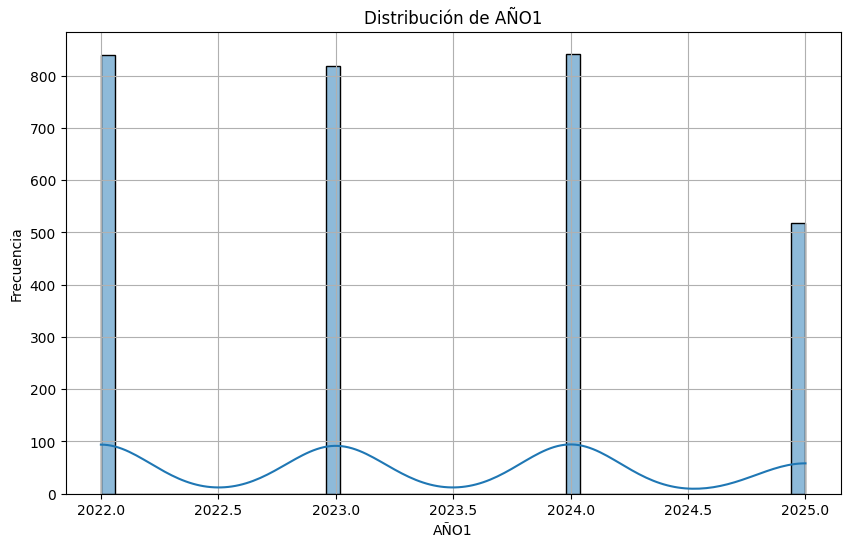

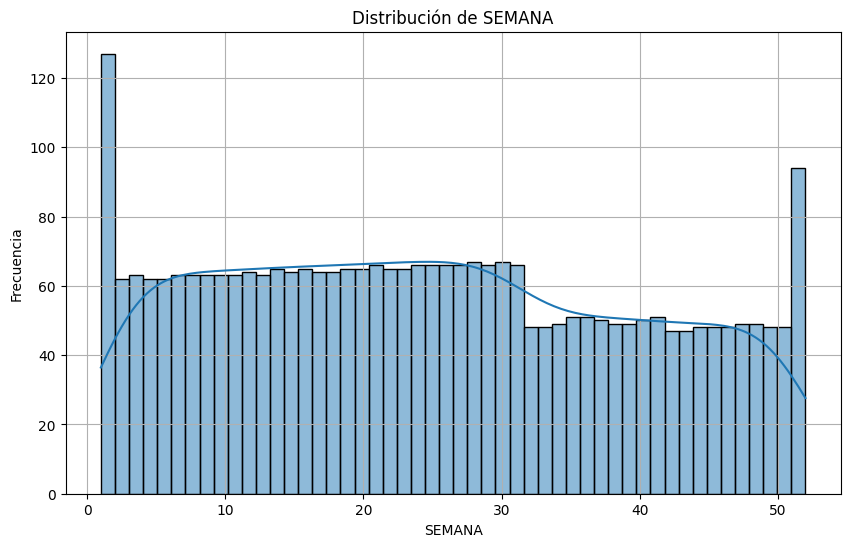

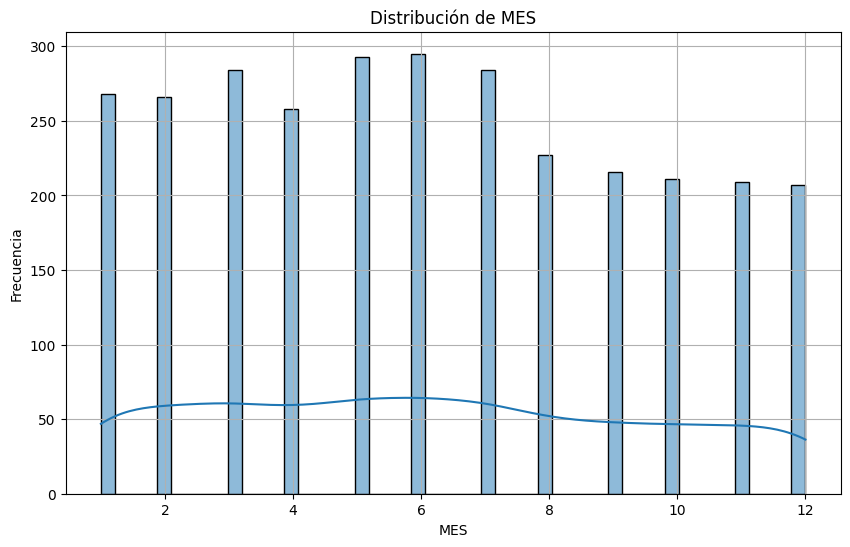

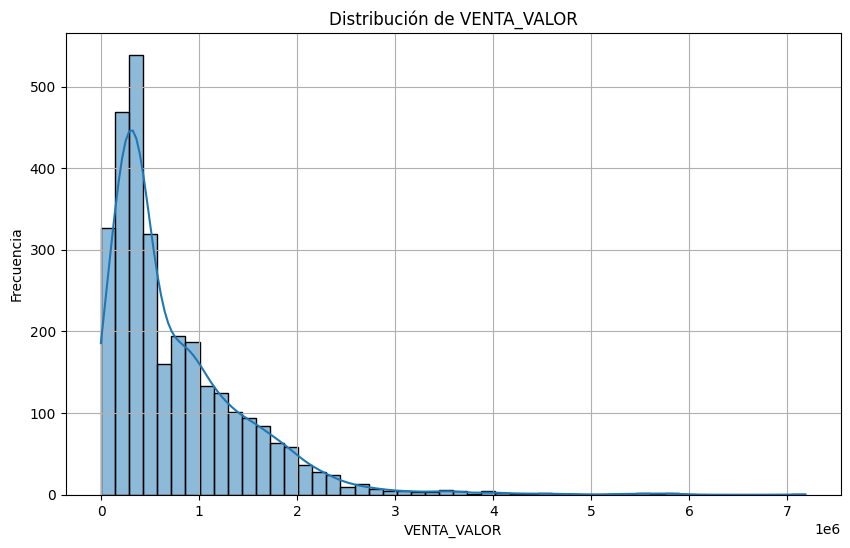

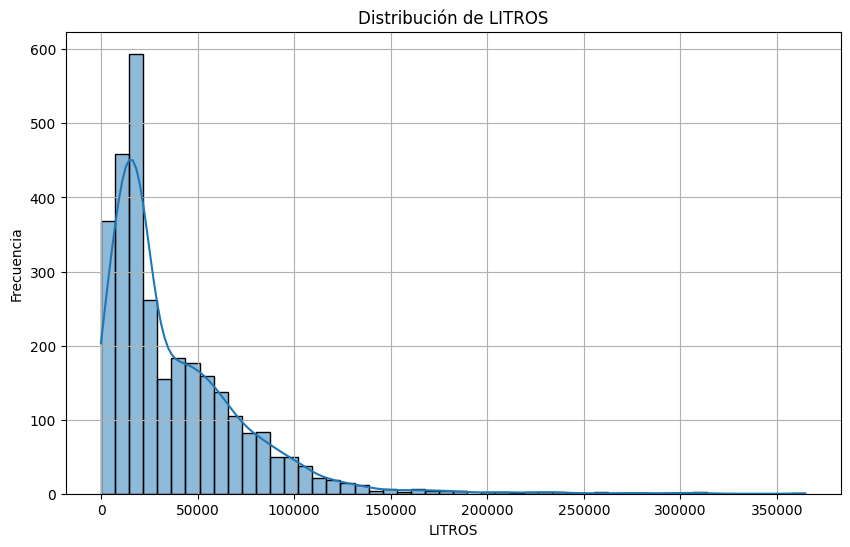

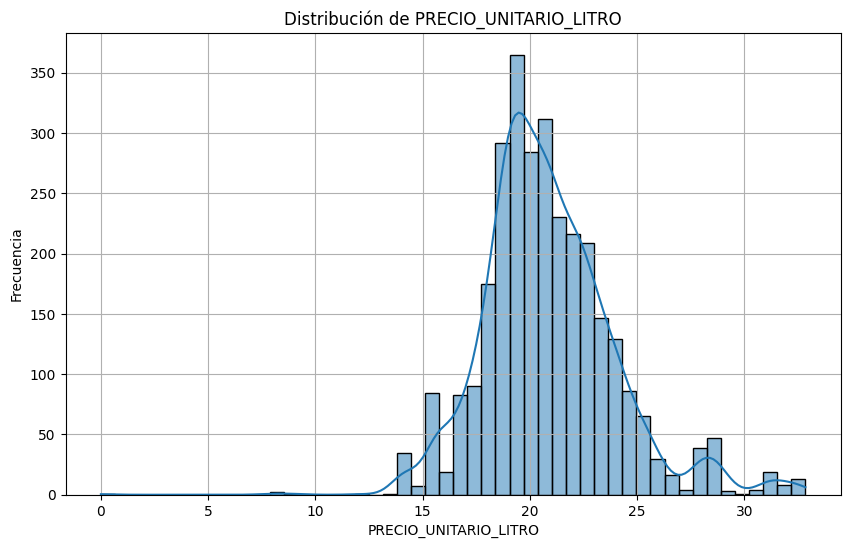

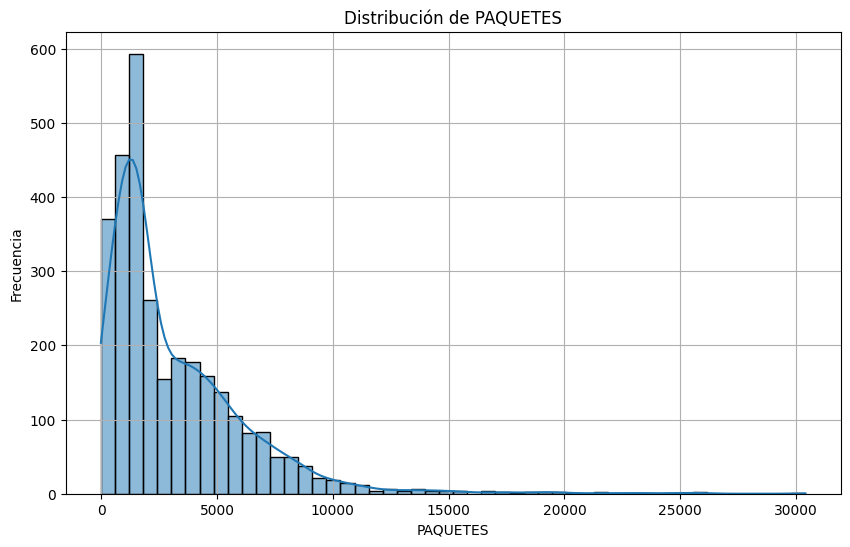

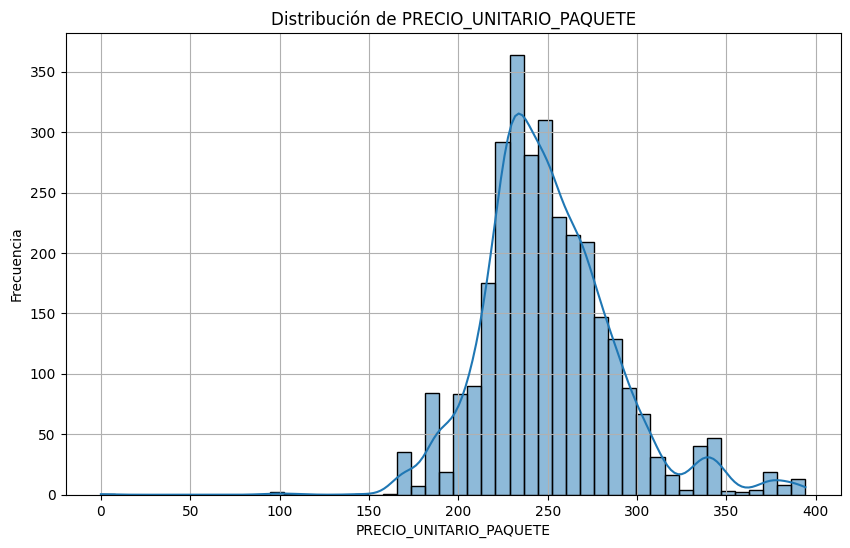

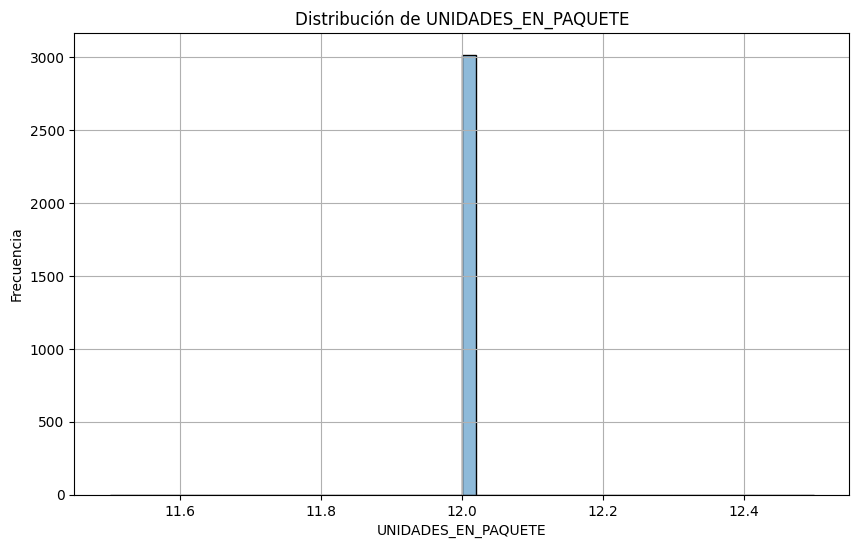

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.show()

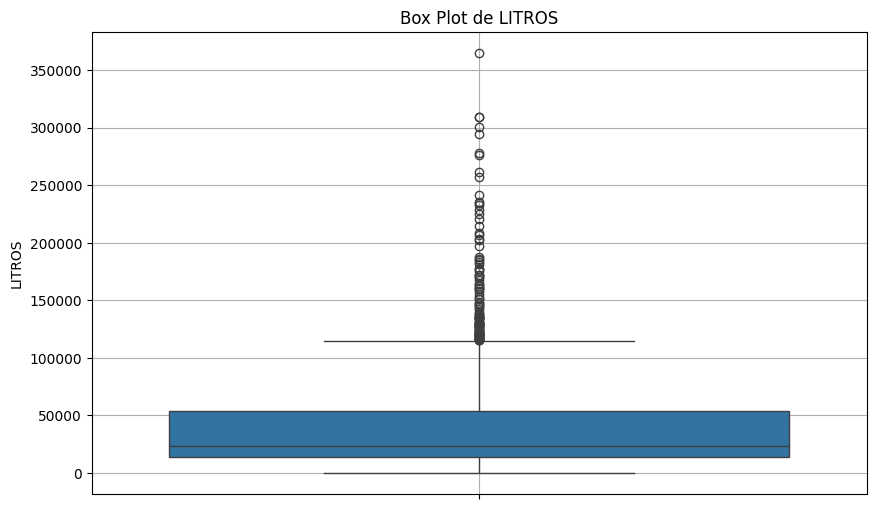

In [ ]:
# Box plot para 'LITROS'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['LITROS'])
plt.title('Box Plot de LITROS')
plt.ylabel('LITROS')
plt.grid(True)
plt.show()

3. Vamos a revisar si hay inconsistencias donde un mismo producto tenga múltiples IDs o un mismo ID tenga múltiples nombres.

In [ ]:
# 1. Verificar si un mismo 'PRODUCTO' tiene mùltiples 'ID's
product_name_to_id = df.groupby('PRODUCTO')['ID'].nunique()
multiple_ids_for_product = product_name_to_id[product_name_to_id > 1]

if not multiple_ids_for_product.empty:
    print("--- Productos con mùltiples IDs ---")
    for product_name in multiple_ids_for_product.index:
        print(f"\nProducto: '{product_name}'")
        display(df[df['PRODUCTO'] == product_name][['PRODUCTO', 'ID']].drop_duplicates())
else:
    print("No se encontraron productos con el mismo nombre y mùltiples IDs.")

No se encontraron productos con el mismo nombre y mùltiples IDs.


In [ ]:
# 2. Verificar si un mismo 'ID' tiene mùltiples 'PRODUCTO's (nombres)
id_to_product_name = df.groupby('ID')['PRODUCTO'].nunique()
multiple_names_for_id = id_to_product_name[id_to_product_name > 1]

if not multiple_names_for_id.empty:
    print("\n--- IDs con mùltiples nombres de productos ---")
    for product_id in multiple_names_for_id.index:
        print(f"\nID: '{product_id}'")
        display(df[df['ID'] == product_id][['PRODUCTO', 'ID']].drop_duplicates())
else:
    print("No se encontraron IDs con mùltiples nombres de productos.")

No se encontraron IDs con mùltiples nombres de productos.


4. Nos ayudaremos de la función describe() de pandas para ver alguna anomalía.

In [ ]:
display(df.describe())

,AÑO1,SEMANA,MES,FECHAW,FECHAM,UNIDADES_EN_PAQUETE,VENTA_VALOR,LITROS,PAQUETES,PRECIO_UNITARIO_LITRO,PRECIO_UNITARIO_PAQUETE
count,3018.000000,3018.000000,3018.000000,3018,3018,3018.0,3.018000e+03,3018.000000,3018.000000,3018.000000,3018.000000
mean,2023.344930,24.900265,6.149768,2023-10-21 20:33:23.976143360,2023-10-10 02:38:24.572564480,12.0,7.597619e+05,37621.300199,3134.656726,20.895583,250.912859
min,2022.000000,1.000000,1.000000,2022-01-03 00:00:00,2022-01-01 00:00:00,12.0,-3.378010e+03,-156.000000,-13.000000,0.000000,0.000000
25%,2022.000000,12.250000,3.000000,2022-11-21 00:00:00,2022-11-01 00:00:00,12.0,2.763866e+05,13515.000000,1126.000000,18.995100,227.941198
50%,2023.000000,24.000000,6.000000,2023-10-23 00:00:00,2023-10-01 00:00:00,12.0,4.931567e+05,23274.000000,1939.500000,20.542726,246.580813
75%,2024.000000,37.000000,9.000000,2024-09-16 00:00:00,2024-09-01 00:00:00,12.0,1.070314e+06,54069.000000,4505.750000,22.482119,270.056137
max,2025.000000,52.000000,12.000000,2025-07-28 00:00:00,2025-07-01 00:00:00,12.0,7.183943e+06,364836.000000,30403.000000,32.851867,394.222407
std,1.061254,14.620999,3.354945,NaN,NaN,0.0,7.243604e+05,36879.201514,3073.588175,3.100774,37.352492


5. En el paso anterior identificamos valores negativos en 3 tablas, verificaremos nuevamente. Identificaremos el numero de filas y confirmar que sean devoluciones.


In [ ]:
print("--- Valores negativos en 'VENTA_VALOR' ---")
negative_venta_valor = df[df['VENTA_VALOR'] < 0]
if not negative_venta_valor.empty:
    display(negative_venta_valor[['VENTA_VALOR']])
else:
    print("No se encontraron valores negativos en 'VENTA_VALOR'.")

print("\n--- Valores negativos en 'PAQUETES' ---")
negative_paquetes = df[df['PAQUETES'] < 0]
if not negative_paquetes.empty:
    display(negative_paquetes[['PAQUETES']])
else:
    print("No se encontraron valores negativos en 'PAQUETES'.")

print("\n--- Valores negativos en 'LITROS' ---")
negative_litros = df[df['LITROS'] < 0]
if not negative_litros.empty:
    display(negative_litros[['LITROS']])
else:
    print("No se encontraron valores negativos en 'LITROS'.")

--- Valores negativos en 'VENTA_VALOR' ---


,VENTA_VALOR
1304,-3378.01
3016,-1020.00



--- Valores negativos en 'PAQUETES' ---


,PAQUETES
1304,-13
3016,-5



--- Valores negativos en 'LITROS' ---


,LITROS
1304,-156
3016,-60


6. Devoluciones que quedaron sueltas, las eliminaremos.

Antes

Debido a que la cantidad de filas es minima, tomare la decisión de corregir esos valores.

In [ ]:
df = df[~((df['VENTA_VALOR'] < 0) | (df['PAQUETES'] < 0) | (df['LITROS'] < 0))].copy()

print("\nValores negativos en df después de aplicar la corrección:")
for col in ['VENTA_VALOR', 'PAQUETES', 'LITROS']:
    negative_values = df[df[col] < 0]
    if not negative_values.empty:
        print(f"  Columna '{col}': {len(negative_values)} valores negativos.")
    else:
        print(f"  Columna '{col}': No hay valores negativos.")


Valores negativos en df después de aplicar la corrección:
  Columna 'VENTA_VALOR': No hay valores negativos.
  Columna 'PAQUETES': No hay valores negativos.
  Columna 'LITROS': No hay valores negativos.


7. Verificaremos que la relación entre columnas de precio sea correcta.

Se detecto que UNIDADES_EN_PAQUETE es una constante de 12 en todo el dataset, lo cual es incorrecto para el producto ENTERA 1.5LT 10PZ del FAB2. El PRECIO_UNITARIO_LITRO original del archivo estaba calculado con ese supuesto erróneo, y nuestro precio ponderado, recalculado directo de VENTA_VALOR/LITROS, lo corrige.

In [ ]:
def verificar_relacion_precios(df_input):
    # Calcular el precio del paquete esperado
    df_input['PRECIO_PAQUETE_CALCULADO'] = df_input['UNIDADES_EN_PAQUETE'] * df_input['PRECIO_UNITARIO_LITRO']

    # Identificar filas donde la relación no se cumple (usando una tolerancia por errores de punto flotante)
    # Por ejemplo, una diferencia absoluta mayor a 0.01
    inconsistencias = df_input[abs(df_input['PRECIO_UNITARIO_PAQUETE'] - df_input['PRECIO_PAQUETE_CALCULADO']) > 0.01]

    if not inconsistencias.empty:
        print("Se encontraron las siguientes inconsistencias en la relación PRECIO_UNITARIO_PAQUETE = UNIDADES_EN_PAQUETE * PRECIO_UNITARIO_LITRO:")
        display(inconsistencias[['PRODUCTO', 'UNIDADES_EN_PAQUETE', 'PRECIO_UNITARIO_LITRO', 'PRECIO_UNITARIO_PAQUETE', 'PRECIO_PAQUETE_CALCULADO']])
    else:
        print("La relación PRECIO_UNITARIO_PAQUETE = UNIDADES_EN_PAQUETE * PRECIO_UNITARIO_LITRO se cumple en todo el DataFrame (con una tolerancia de 0.01).")

    # Eliminar la columna temporal de cálculo si no se necesita
    return df_input.drop(columns=['PRECIO_PAQUETE_CALCULADO'])

# Aplicar la función a df
df = verificar_relacion_precios(df)

Se encontraron las siguientes inconsistencias en la relación PRECIO_UNITARIO_PAQUETE = UNIDADES_EN_PAQUETE * PRECIO_UNITARIO_LITRO:


,PRODUCTO,UNIDADES_EN_PAQUETE,PRECIO_UNITARIO_LITRO,PRECIO_UNITARIO_PAQUETE,PRECIO_PAQUETE_CALCULADO
1859,FAB2_ ENTERA 1.5LT 10PZ,12,24.091852,361.377778,289.102222
1860,FAB2_ ENTERA 1.5LT 10PZ,12,22.294175,334.412621,267.530097
1861,FAB2_ ENTERA 1.5LT 10PZ,12,20.417302,306.259528,245.007623
1862,FAB2_ ENTERA 1.5LT 10PZ,12,19.935687,299.035300,239.228240
1863,FAB2_ ENTERA 1.5LT 10PZ,12,20.057643,300.864639,240.691711
1864,FAB2_ ENTERA 1.5LT 10PZ,12,20.907799,313.616982,250.893586
1865,FAB2_ ENTERA 1.5LT 10PZ,12,19.217452,288.261786,230.609429
1866,FAB2_ ENTERA 1.5LT 10PZ,12,19.935070,299.026045,239.220836


8. Usaremos FECHAM y construiremos el panel mensual.

El panel mensual esta en long format, lo que nos permitira más adelante hacer nuestra regresión lineal. Usamos FECHAM y no el mes de FECHAW porque hay semanas que caen en dos meses distintos, y si sacamos el mes de la fecha semanal partimos mal esas semanas.

Este panel es el que vamos a usar para modelar más adelante, no las filas semanales.

In [ ]:
# Eliminar columnas de df
df = df.drop(columns=['UNIDADES_EN_PAQUETE', 'AÑO1', 'SEMANA', 'MES'])

print("Columnas eliminadas de df. Las columnas restantes son:")
print(df.columns)

venta_antes_panel = df['VENTA_VALOR'].sum()
litros_antes_panel = df['LITROS'].sum()

# Panel mensual usando FECHAM
df['AÑO_MES'] = df['FECHAM'].dt.to_period('M')
panel_mensual = df.groupby(['FABRICANTE', 'ID', 'AÑO_MES'], as_index=False).agg(
    PRODUCTO=('PRODUCTO', 'first'),
    VENTA_VALOR=('VENTA_VALOR', 'sum'),
    LITROS=('LITROS', 'sum'),
)
# Otra vez precio ponderado, ahora a nivel producto-mes
panel_mensual['PRECIO_UNITARIO_LITRO'] = panel_mensual['VENTA_VALOR'] / panel_mensual['LITROS']

print(f"\nFilas del panel mensual: {len(panel_mensual)}")
print(f"Meses distintos: {panel_mensual['AÑO_MES'].nunique()} (de {panel_mensual['AÑO_MES'].min()} a {panel_mensual['AÑO_MES'].max()})")
print(f"SKUs distintos: {panel_mensual['ID'].nunique()}")

# Comprobamos que el colapso semanal -> mensual tampoco pierda totales
print("\n--- Conservación de totales en el colapso mensual ---")
print(f"VENTA_VALOR semanal: {venta_antes_panel:,.2f} | mensual: {panel_mensual['VENTA_VALOR'].sum():,.2f} | diferencia: {panel_mensual['VENTA_VALOR'].sum() - venta_antes_panel:,.6f}")
print(f"LITROS semanal: {litros_antes_panel:,.2f} | mensual: {panel_mensual['LITROS'].sum():,.2f} | diferencia: {panel_mensual['LITROS'].sum() - litros_antes_panel:,.6f}")

display(panel_mensual.head())

Columnas eliminadas de df. Las columnas restantes son:
Index(['FABRICANTE', 'ID', 'PRODUCTO', 'CORTE', 'FECHAW', 'FECHAM',
       'VENTA_VALOR', 'LITROS', 'PAQUETES', 'PRECIO_UNITARIO_LITRO',
       'PRECIO_UNITARIO_PAQUETE'],
      dtype='object')

Filas del panel mensual: 709
Meses distintos: 43 (de 2022-01 a 2025-07)
SKUs distintos: 26

--- Conservación de totales en el colapso mensual ---
VENTA_VALOR semanal: 2,292,965,939.86 | mensual: 2,292,965,939.86 | diferencia: 0.000000
LITROS semanal: 113,541,300.00 | mensual: 113,541,300.00 | diferencia: 0.000000


,FABRICANTE,ID,AÑO_MES,PRODUCTO,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO
0,FAB1,1L Sel Des Deslactosada,2022-04,FAB1_1L Sel Des Deslactosada,219798.22,11064,19.866072
1,FAB1,1L Sel Des Deslactosada,2022-05,FAB1_1L Sel Des Deslactosada,338979.66,16980,19.963466
2,FAB1,1L Sel Des Deslactosada,2022-06,FAB1_1L Sel Des Deslactosada,687224.59,34860,19.713844
3,FAB1,1L Sel Des Deslactosada,2022-07,FAB1_1L Sel Des Deslactosada,723623.35,36588,19.777614
4,FAB1,1L Sel Des Deslactosada,2022-08,FAB1_1L Sel Des Deslactosada,769971.83,38580,19.957798


## Etapa 2

1. Market Share anual por fabricante

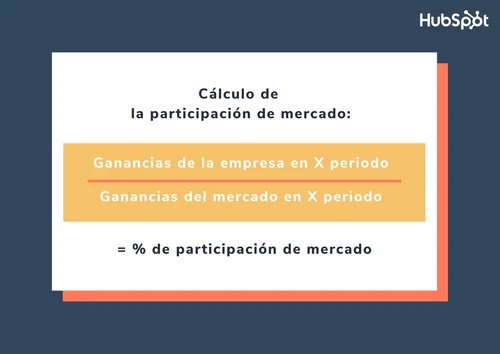

In [ ]:
# Asegurarse de que 'FECHAW' sea tipo datetime
df['FECHAW'] = pd.to_datetime(df['FECHAW'])

# Extraer el año de 'FECHAW'
df['AÑO'] = df['FECHAW'].dt.year

# Calcular las ventas anuales por fabricante
annual_sales_by_manufacturer = df.groupby(['AÑO', 'FABRICANTE'])['VENTA_VALOR'].sum().reset_index()
annual_sales_by_manufacturer.rename(columns={'VENTA_VALOR': 'VENTA_ANUAL'}, inplace=True)

# Calcular el total de ventas anuales
total_annual_sales = annual_sales_by_manufacturer.groupby('AÑO')['VENTA_ANUAL'].sum().reset_index()
total_annual_sales.rename(columns={'VENTA_ANUAL': 'TOTAL_VENTA_ANUAL'}, inplace=True)

# Unir para calcular la cuota de mercado (Market Share)
market_share_df = pd.merge(annual_sales_by_manufacturer, total_annual_sales, on='AÑO')
market_share_df['MARKET_SHARE'] = (market_share_df['VENTA_ANUAL'] / market_share_df['TOTAL_VENTA_ANUAL']) * 100

# Mostrar el resultado
display(market_share_df.sort_values(by=['AÑO', 'MARKET_SHARE'], ascending=[True, False]))

,AÑO,FABRICANTE,VENTA_ANUAL,TOTAL_VENTA_ANUAL,MARKET_SHARE
0,2022,FAB1,2.634132e+08,5.901269e+08,44.636707
2,2022,FAB3,1.853947e+08,5.901269e+08,31.416076
1,2022,FAB2,1.240779e+08,5.901269e+08,21.025637
3,2022,FAB6,1.724103e+07,5.901269e+08,2.921580
4,2023,FAB1,2.835175e+08,6.106364e+08,46.429845
6,2023,FAB3,1.766527e+08,6.106364e+08,28.929271
5,2023,FAB2,1.382942e+08,6.106364e+08,22.647547
7,2023,FAB6,1.217204e+07,6.106364e+08,1.993337
8,2024,FAB1,2.796043e+08,6.774311e+08,41.274209
10,2024,FAB3,2.132826e+08,6.774311e+08,31.484036


Aquí se muestra la cuota de mercado anual para cada fabricante, ordenada por año y luego por el porcentaje de cuota de mercado de forma descendente.

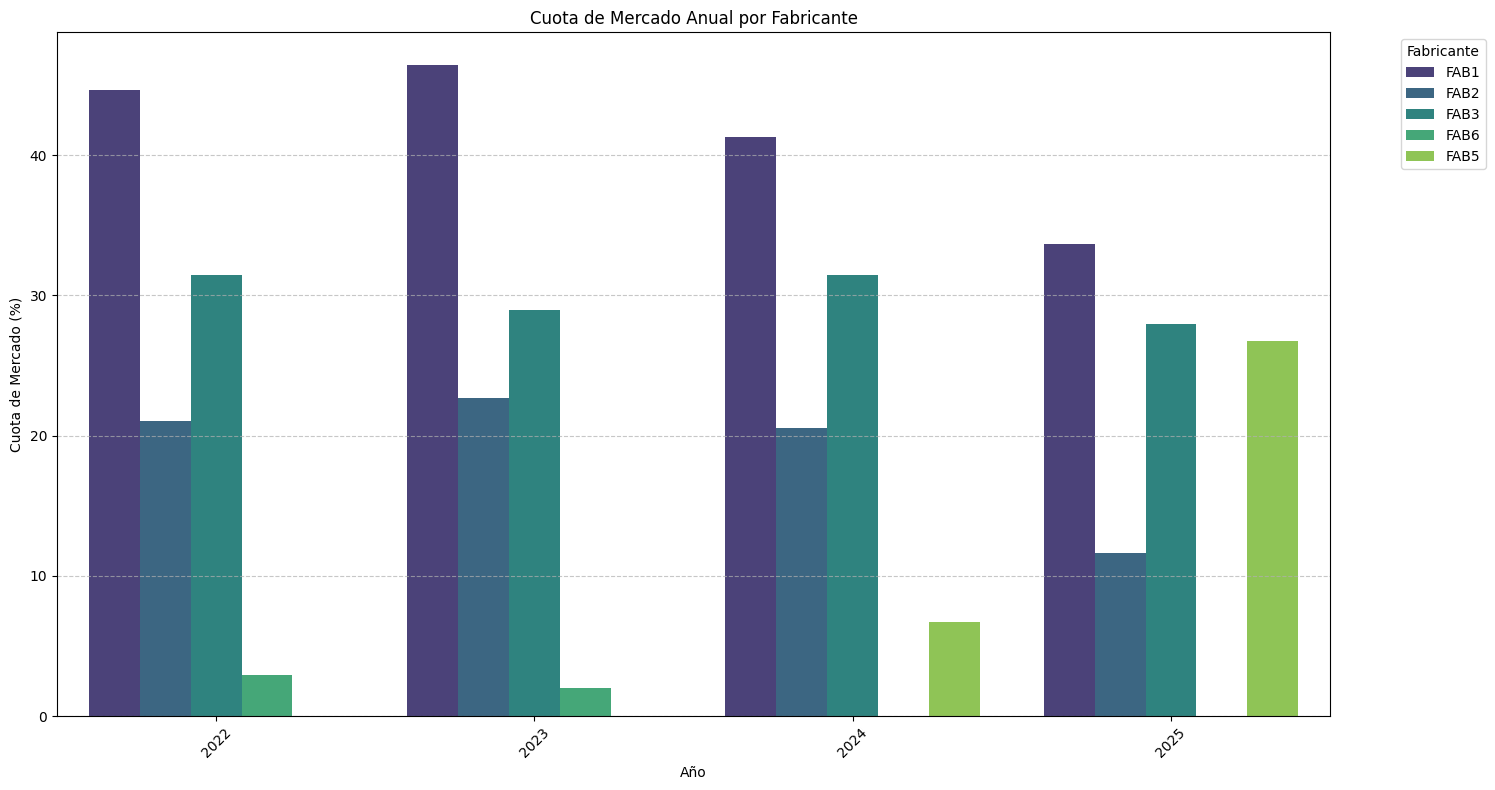

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico de barras para visualizar el Market Share anual por fabricante
plt.figure(figsize=(15, 8))
sns.barplot(x='AÑO', y='MARKET_SHARE', hue='FABRICANTE', data=market_share_df, palette='viridis')

plt.title('Cuota de Mercado Anual por Fabricante')
plt.xlabel('Año')
plt.ylabel('Cuota de Mercado (%)')
plt.xticks(rotation=45) # Rotar las etiquetas del eje x para mejor legibilidad
plt.legend(title='Fabricante', bbox_to_anchor=(1.05, 1), loc='upper left') # Mover la leyenda fuera del gráfico
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Ajustar el diseño para evitar solapamientos
plt.show()

Podemos observar la participación constante de los fabricantes 1, 2, y 3 a lo largo de las años. Tambien podemos observar la incorporación del fabricante 5 luego de la salida del fabricante 6. Ese ultimo cambio puede ser un re-branding de la marca.

In [ ]:
# market_share_latest_year = market_share_df[market_share_df['AÑO'] == latest_year].copy()
latest_year = market_share_df['AÑO'].max()  # se conserva solo para referencia en textos

fecha_max = df['FECHAW'].max()
fecha_corte = fecha_max - pd.DateOffset(months=12)
df_ult12m = df[df['FECHAW'] > fecha_corte]

ventas_12m = df_ult12m.groupby('FABRICANTE')['VENTA_VALOR'].sum().reset_index()
ventas_12m.rename(columns={'VENTA_VALOR': 'VENTA_ANUAL'}, inplace=True)
ventas_12m['MARKET_SHARE'] = ventas_12m['VENTA_ANUAL'] / ventas_12m['VENTA_ANUAL'].sum() * 100
market_share_latest_year = ventas_12m.sort_values(by='MARKET_SHARE', ascending=False).copy()

# Ordenar por cuota de mercado de forma descendente
# market_share_latest_year = market_share_latest_year.sort_values(by='MARKET_SHARE', ascending=False)  # ya viene ordenado arriba

# Calcular la cuota de mercado acumulada
market_share_latest_year['CUM_MARKET_SHARE'] = market_share_latest_year['MARKET_SHARE'].cumsum()

# Identificar los fabricantes que conforman el 80% de la cuota de mercado
top_80_percent_fabs = market_share_latest_year[market_share_latest_year['CUM_MARKET_SHARE'] <= 80]

# Si el último fabricante añadido excede el 80% pero su inclusión es necesaria para pasar el umbral
# Se podría añadir una lógica para incluirlo si es el caso, pero para un Pareto estricto se mantiene así.

print(f"\nLos fabricantes que conforman el 80% de la cuota de mercado (últimos 12 meses) son:")
display(top_80_percent_fabs[['FABRICANTE', 'MARKET_SHARE', 'CUM_MARKET_SHARE']])

# Para incluir el primer fabricante que hace que el acumulado supere el 80%
if top_80_percent_fabs.empty and not market_share_latest_year.empty:
    # Si no hay fabricantes por debajo del 80% (ej. el primero ya es > 80%), tomamos el primero
    top_80_percent_fabs_extended = market_share_latest_year.iloc[[0]]
elif not top_80_percent_fabs.empty and top_80_percent_fabs['CUM_MARKET_SHARE'].iloc[-1] < 80:
    # Si el último fabricante añadido no alcanzó el 80% y hay más fabricantes por añadir
    # Encontramos el índice del primer fabricante que hace que el acumulado supere el 80%
    index_first_above_80 = (market_share_latest_year['CUM_MARKET_SHARE'] > 80).idxmax()
    # Incluimos todos los fabricantes hasta ese punto
    top_80_percent_fabs_extended = market_share_latest_year.loc[:index_first_above_80]
else:
    top_80_percent_fabs_extended = top_80_percent_fabs

print(f"\nConsiderando los fabricantes que contribuyen al 80% (incluyendo el último que lo supera) (últimos 12 meses):")
display(top_80_percent_fabs_extended[['FABRICANTE', 'MARKET_SHARE', 'CUM_MARKET_SHARE']])


Los fabricantes que conforman el 80% de la cuota de mercado (últimos 12 meses) son:


,FABRICANTE,MARKET_SHARE,CUM_MARKET_SHARE
0,FAB1,35.932638,35.932638
2,FAB3,28.716002,64.648640



Considerando los fabricantes que contribuyen al 80% (incluyendo el último que lo supera) (últimos 12 meses):


,FABRICANTE,MARKET_SHARE,CUM_MARKET_SHARE
0,FAB1,35.932638,35.932638
2,FAB3,28.716002,64.648640
3,FAB5,22.000764,86.649404


In [ ]:
print("\nCuota de mercado de todos los fabricantes (últimos 12 meses, ordenado):")
display(market_share_latest_year[['FABRICANTE', 'MARKET_SHARE']])


Cuota de mercado de todos los fabricantes (últimos 12 meses, ordenado):


,FABRICANTE,MARKET_SHARE
0,FAB1,35.932638
2,FAB3,28.716002
3,FAB5,22.000764
1,FAB2,13.350596


2.  Análisis Descriptivo de Fabricantes del 80% de Cuota de Mercado

Es importante darse cuenta que el fabricante 2 se mantiene en un rango cercano al fabricante 1 y tiene menor cantidad de productos unicos.

In [ ]:
# Obtener la lista de fabricantes del 80% de la cuota de mercado extendida
top_fabs_list = top_80_percent_fabs_extended['FABRICANTE'].tolist()

print(f"Fabricantes que conforman el 80% de la cuota de mercado extendida: {top_fabs_list}\n")

# Para cada fabricante, contar el número de productos únicos
manufacturer_product_counts = {}
for fab in top_fabs_list:
    # Filtrar el DataFrame principal 'df' para el fabricante actual
    df_fab = df[df['FABRICANTE'] == fab]
    # Contar productos únicos
    unique_products_count = df_fab['PRODUCTO'].nunique()
    manufacturer_product_counts[fab] = unique_products_count

    print(f"Fabricante {fab}: {unique_products_count} productos únicos")

# También podemos ver la cuota de mercado de cada uno de estos fabricantes
print("\nCuota de Mercado (extendida) para el año más reciente:")
display(top_80_percent_fabs_extended[['FABRICANTE', 'MARKET_SHARE', 'CUM_MARKET_SHARE']])

Fabricantes que conforman el 80% de la cuota de mercado extendida: ['FAB1', 'FAB3', 'FAB5']

Fabricante FAB1: 8 productos únicos
Fabricante FAB3: 3 productos únicos
Fabricante FAB5: 3 productos únicos

Cuota de Mercado (extendida) para el año más reciente:


,FABRICANTE,MARKET_SHARE,CUM_MARKET_SHARE
0,FAB1,35.932638,35.932638
2,FAB3,28.716002,64.648640
3,FAB5,22.000764,86.649404


3. Desempeño en el Tiempo: Tendencia de Ventas (Volumen/Dinero) y Precio Medio por Fabricante

Podemos observar que en el ultimo año las ventas de los primeros dos fabricantes disminuyo, posiblemente por la incorparación del fabricante 5 al mercado, quien finalizando el 2025 tuvo mayor volumen que el fabricante 2.

Podemos observar como en el ultimo año el consumo de la leche ha disminuido. Mientras que el precio de la leche incrementa, el consumo de esta disminuye.


Desempeño Anual por Fabricante (Top 80% de Cuota de Mercado):


,AÑO,FABRICANTE,total_venta_valor,total_litros,avg_precio_litro
0,2022,FAB1,2.634132e+08,13865772,18.997371
1,2022,FAB3,1.853947e+08,9600672,19.310597
2,2023,FAB1,2.835175e+08,14540592,19.498350
3,2023,FAB3,1.766527e+08,8685408,20.339018
4,2024,FAB1,2.796043e+08,12988908,21.526392
5,2024,FAB3,2.132826e+08,9606276,22.202427
6,2024,FAB5,4.541621e+07,2428152,18.704023
7,2025,FAB1,1.395615e+08,6189756,22.547179
8,2025,FAB3,1.159922e+08,5038800,23.019801
9,2025,FAB5,1.109548e+08,5670708,19.566296


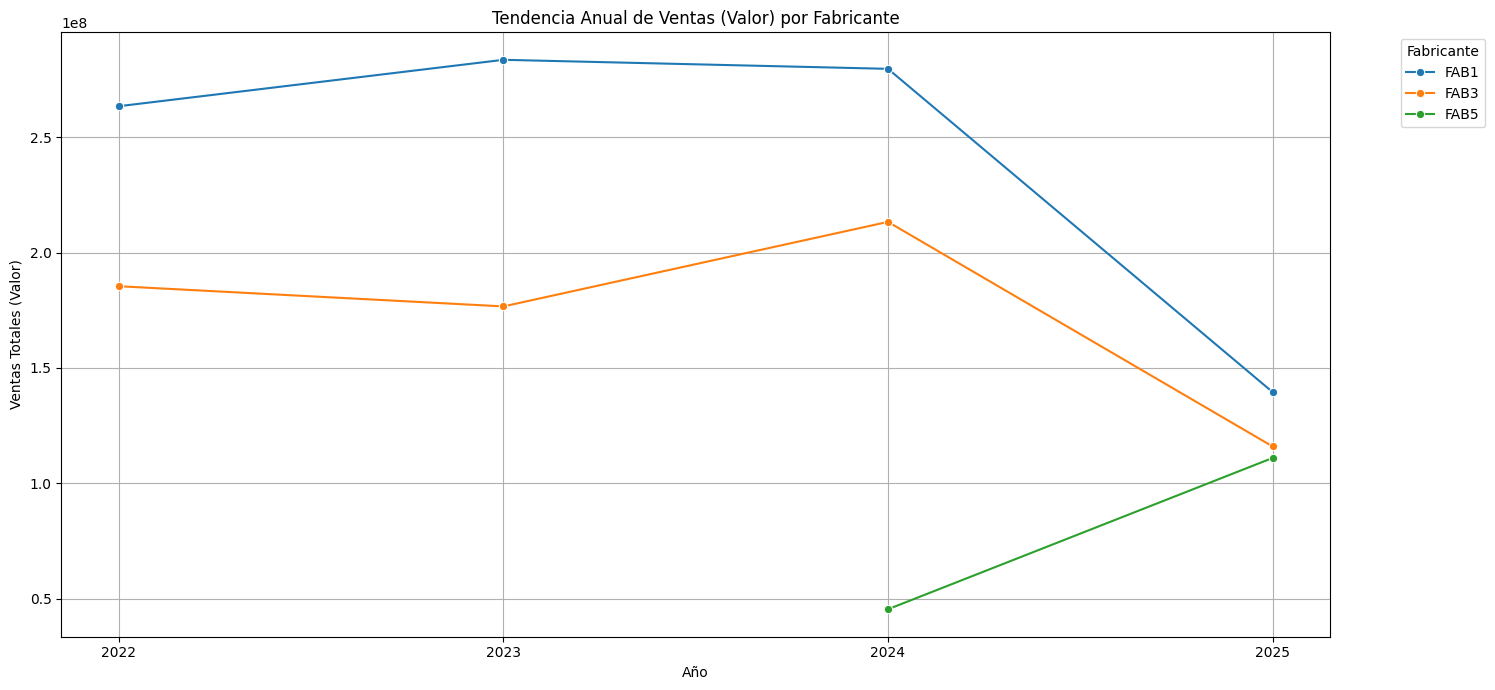

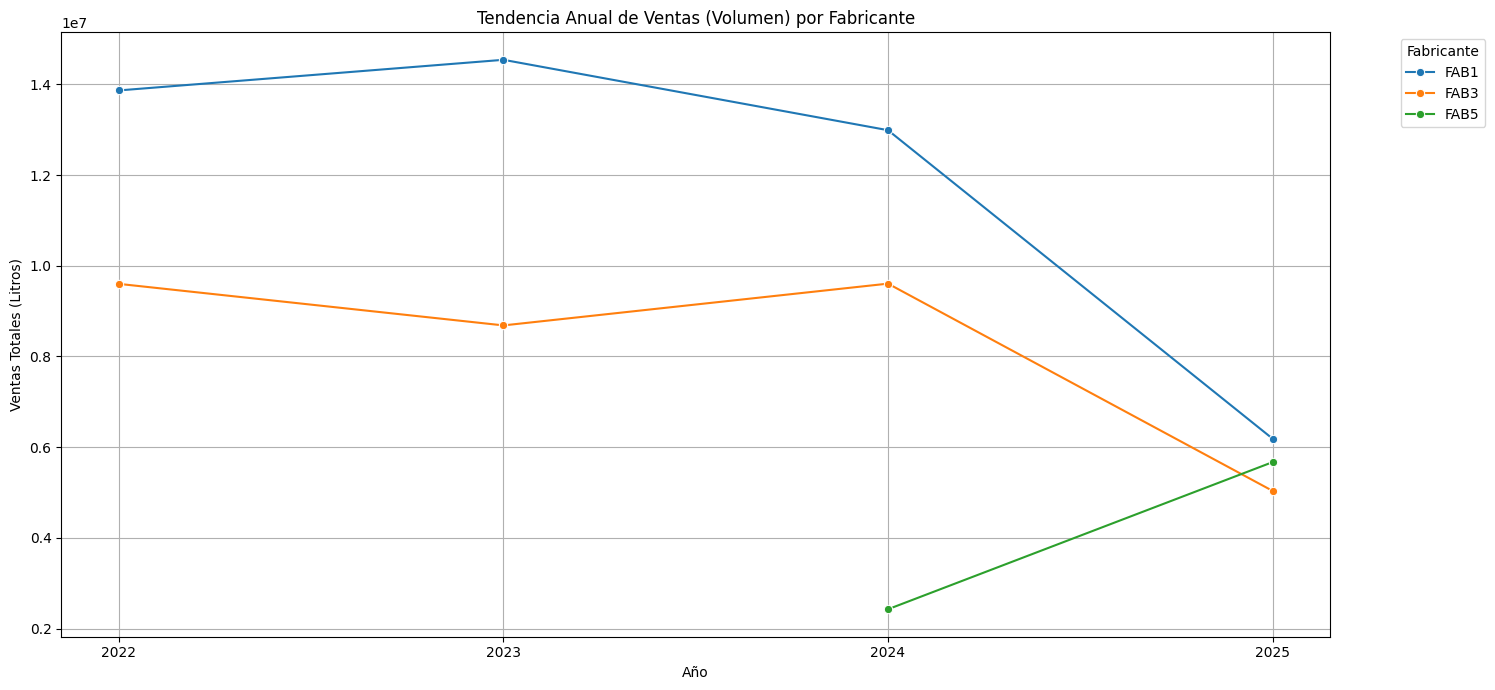

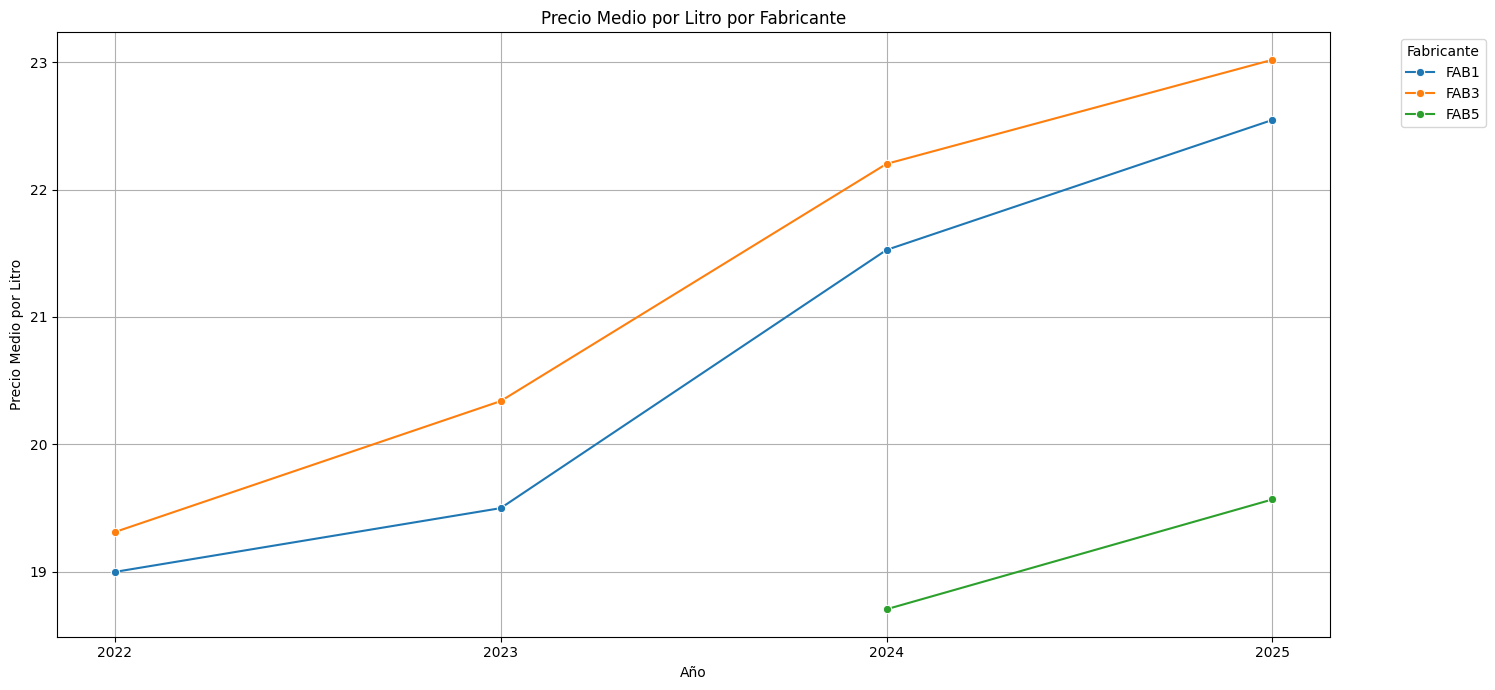

In [ ]:
# Asegurarse de que 'FECHAW' sea tipo datetime y extraer el año
df_performance = df[df['FABRICANTE'].isin(top_fabs_list)].copy()
df_performance['FECHAW'] = pd.to_datetime(df_performance['FECHAW'])
df_performance['AÑO'] = df_performance['FECHAW'].dt.year

annual_performance_by_fab = df_performance.groupby(['AÑO', 'FABRICANTE']).agg(
    total_venta_valor=('VENTA_VALOR', 'sum'),
    total_litros=('LITROS', 'sum'),
).reset_index()

annual_performance_by_fab['avg_precio_litro'] = (
    annual_performance_by_fab['total_venta_valor'] / annual_performance_by_fab['total_litros']
)

# Mostrar el desempeño anual por fabricante
print("\nDesempeño Anual por Fabricante (Top 80% de Cuota de Mercado):")
display(annual_performance_by_fab)

# Visualización de Tendencias de Ventas (Valor) por Fabricante
plt.figure(figsize=(15, 7))
sns.lineplot(data=annual_performance_by_fab, x='AÑO', y='total_venta_valor', hue='FABRICANTE', marker='o')
plt.title('Tendencia Anual de Ventas (Valor) por Fabricante')
plt.xlabel('Año')
plt.ylabel('Ventas Totales (Valor)')
plt.grid(True)
plt.xticks(annual_performance_by_fab['AÑO'].unique())
plt.legend(title='Fabricante', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Visualización de Tendencias de Ventas (Volumen) por Fabricante
plt.figure(figsize=(15, 7))
sns.lineplot(data=annual_performance_by_fab, x='AÑO', y='total_litros', hue='FABRICANTE', marker='o')
plt.title('Tendencia Anual de Ventas (Volumen) por Fabricante')
plt.xlabel('Año')
plt.ylabel('Ventas Totales (Litros)')
plt.grid(True)
plt.xticks(annual_performance_by_fab['AÑO'].unique())
plt.legend(title='Fabricante', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Visualización de Precio Medio por Litro por Fabricante
plt.figure(figsize=(15, 7))
sns.lineplot(data=annual_performance_by_fab, x='AÑO', y='avg_precio_litro', hue='FABRICANTE', marker='o')
plt.title('Precio Medio por Litro por Fabricante')
plt.xlabel('Año')
plt.ylabel('Precio Medio por Litro')
plt.grid(True)
plt.xticks(annual_performance_by_fab['AÑO'].unique())
plt.legend(title='Fabricante', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

4. Desempeño en el Tiempo: Tendencia Mensual de Ventas y Precio Medio por Producto (Últimos 12 Meses)


Desempeño Mensual por Producto (Top 3 productos por fabricante en el 80% de cuota de mercado, Últimos 12 Meses):



,AÑO_MES,FABRICANTE,PRODUCTO,total_venta_valor,total_litros,avg_precio_litro,FECHA
0,2024-07,FAB1,FAB1_Leche Clasica Deslactosada 1 L,1745634.92,84624,20.628131,2024-07-01
1,2024-07,FAB1,FAB1_Leche Clasica Deslactosada Light 1 L,990890.55,46596,21.265571,2024-07-01
2,2024-07,FAB1,FAB1_Leche Clasica Entera 1 L,1840539.33,87120,21.126485,2024-07-01
3,2024-08,FAB1,FAB1_Leche Clasica Deslactosada 1 L,6514858.95,308040,21.149393,2024-08-01
4,2024-08,FAB1,FAB1_Leche Clasica Deslactosada Light 1 L,3775058.14,175164,21.551564,2024-08-01


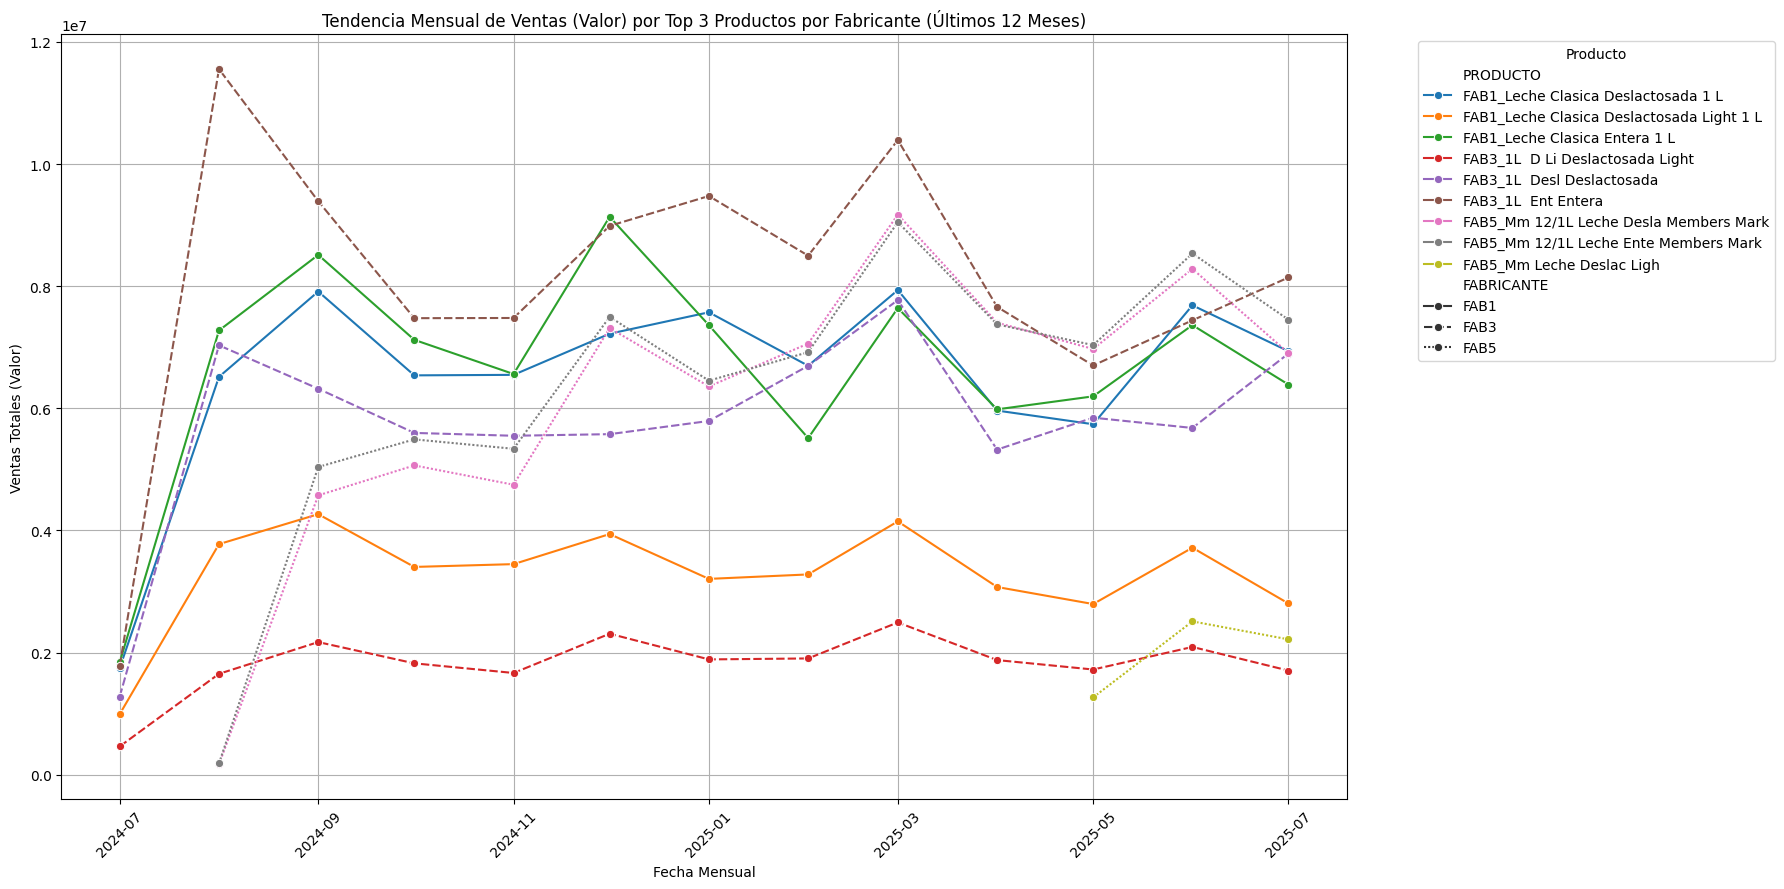

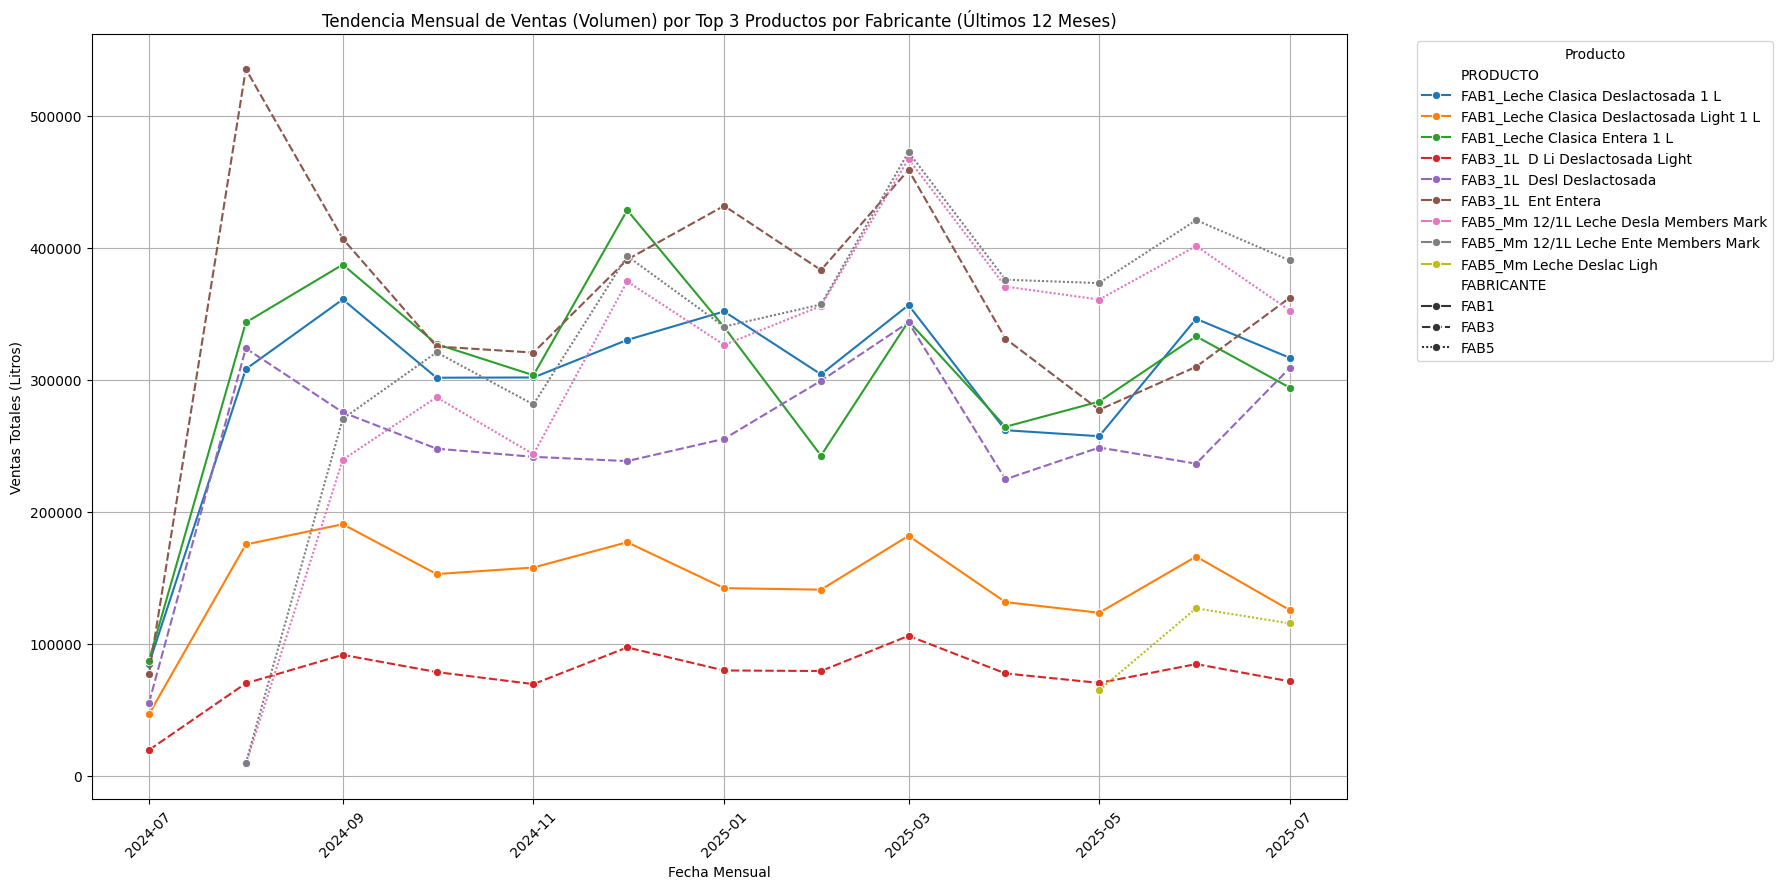

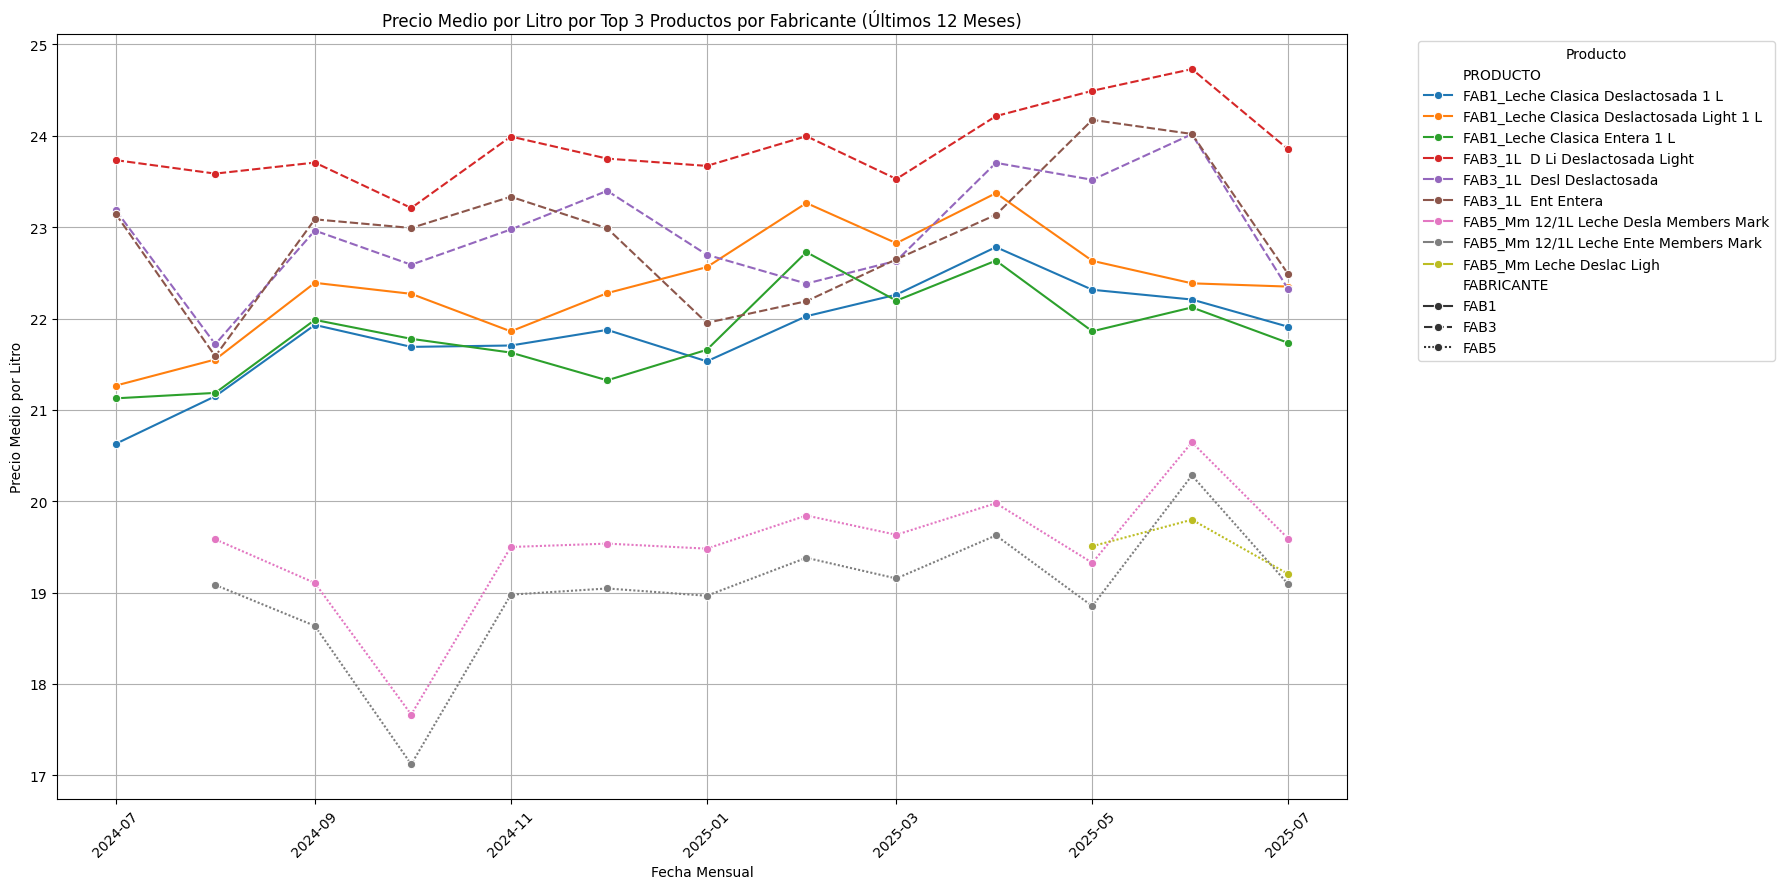

In [ ]:
TOP_N_PRODUCTS = 3 # Reutilizar TOP_N_PRODUCTS

fecha_max_perf = df_performance['FECHAW'].max()
fecha_corte_perf = fecha_max_perf - pd.DateOffset(months=12)
df_last_12_months = df_performance[df_performance['FECHAW'] > fecha_corte_perf].copy()

df_last_12_months_monthly = df_last_12_months.copy()
df_last_12_months_monthly['FECHAW'] = pd.to_datetime(df_last_12_months_monthly['FECHAW'])
df_last_12_months_monthly['AÑO_MES'] = df_last_12_months_monthly['FECHAW'].dt.to_period('M')

product_performance_monthly_dfs = []

for fab in top_fabs_list:
    df_fab_12m_monthly = df_last_12_months_monthly[df_last_12_months_monthly['FABRICANTE'] == fab]

    # Calcular ventas totales por producto para identificar los top N dentro de los últimos 12 meses
    total_sales_per_product_12m_monthly = df_fab_12m_monthly.groupby('PRODUCTO')['VENTA_VALOR'].sum().reset_index()
    top_products_for_fab_12m_monthly = total_sales_per_product_12m_monthly.nlargest(TOP_N_PRODUCTS, 'VENTA_VALOR')['PRODUCTO'].tolist()

    # Filtrar el DataFrame para solo los top N productos de este fabricante en los últimos 12 meses
    df_fab_top_products_12m_monthly = df_fab_12m_monthly[df_fab_12m_monthly['PRODUCTO'].isin(top_products_for_fab_12m_monthly)]

    # Agrupar por mes, fabricante y producto para ventas totales (dinero y volumen) y precio medio
    monthly_product_performance_12m = df_fab_top_products_12m_monthly.groupby(['AÑO_MES', 'FABRICANTE', 'PRODUCTO']).agg(
        total_venta_valor=('VENTA_VALOR', 'sum'),
        total_litros=('LITROS', 'sum'),
    ).reset_index()
    monthly_product_performance_12m['avg_precio_litro'] = (
        monthly_product_performance_12m['total_venta_valor'] / monthly_product_performance_12m['total_litros']
    )
    product_performance_monthly_dfs.append(monthly_product_performance_12m)

if product_performance_monthly_dfs:
    all_product_performance_monthly = pd.concat(product_performance_monthly_dfs)
    # Convertir 'AÑO_MES' de Period a Timestamp para el eje x de los gráficos
    all_product_performance_monthly['FECHA'] = all_product_performance_monthly['AÑO_MES'].dt.to_timestamp()

    print(f"\nDesempeño Mensual por Producto (Top {TOP_N_PRODUCTS} productos por fabricante en el 80% de cuota de mercado, Últimos 12 Meses):\n")
    display(all_product_performance_monthly.head())

    # Visualización de Tendencias de Ventas (Valor) por Producto
    plt.figure(figsize=(18, 9))
    sns.lineplot(data=all_product_performance_monthly, x='FECHA', y='total_venta_valor', hue='PRODUCTO', style='FABRICANTE', marker='o')
    plt.title(f'Tendencia Mensual de Ventas (Valor) por Top {TOP_N_PRODUCTS} Productos por Fabricante (Últimos 12 Meses)')
    plt.xlabel('Fecha Mensual')
    plt.ylabel('Ventas Totales (Valor)')
    plt.grid(True)
    plt.xticks(rotation=45) # Rotate x-axis labels
    plt.legend(title='Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Visualización de Tendencias de Ventas (Volumen) por Producto
    plt.figure(figsize=(18, 9))
    sns.lineplot(data=all_product_performance_monthly, x='FECHA', y='total_litros', hue='PRODUCTO', style='FABRICANTE', marker='o')
    plt.title(f'Tendencia Mensual de Ventas (Volumen) por Top {TOP_N_PRODUCTS} Productos por Fabricante (Últimos 12 Meses)')
    plt.xlabel('Fecha Mensual')
    plt.ylabel('Ventas Totales (Litros)')
    plt.grid(True)
    plt.xticks(rotation=45) # Rotate x-axis labels
    plt.legend(title='Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Visualización de Precio Medio por Litro por Producto
    plt.figure(figsize=(18, 9))
    sns.lineplot(data=all_product_performance_monthly, x='FECHA', y='avg_precio_litro', hue='PRODUCTO', style='FABRICANTE', marker='o')
    plt.title(f'Precio Medio por Litro por Top {TOP_N_PRODUCTS} Productos por Fabricante (Últimos 12 Meses)')
    plt.xlabel('Fecha Mensual')
    plt.ylabel('Precio Medio por Litro')
    plt.grid(True)
    plt.xticks(rotation=45) # Rotate x-axis labels
    plt.legend(title='Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron datos de productos para los fabricantes principales en los últimos 12 meses.")

5. Analisis de correlación.

    a. Identificar variables clave
        
      Nuestras variables claves deben ser medibles, osea no categoricas, como lo pueden ser fabricante, ID, producto, o fecha.

        Variables clave:
          Venta valor
          Litros
          Precio_unitario_litro
          Paquetes
          Precio_unitario_paquete

    b. Calcular la matriz de correlación de todos los fabricantes

,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE
VENTA_VALOR,1.000000,0.991799,-0.161256,0.991798,-0.164075
LITROS,0.991799,1.000000,-0.231048,0.999995,-0.233507
PRECIO_UNITARIO_LITRO,-0.161256,-0.231048,1.000000,-0.230991,0.996261
PAQUETES,0.991798,0.999995,-0.230991,1.000000,-0.233687
PRECIO_UNITARIO_PAQUETE,-0.164075,-0.233507,0.996261,-0.233687,1.000000


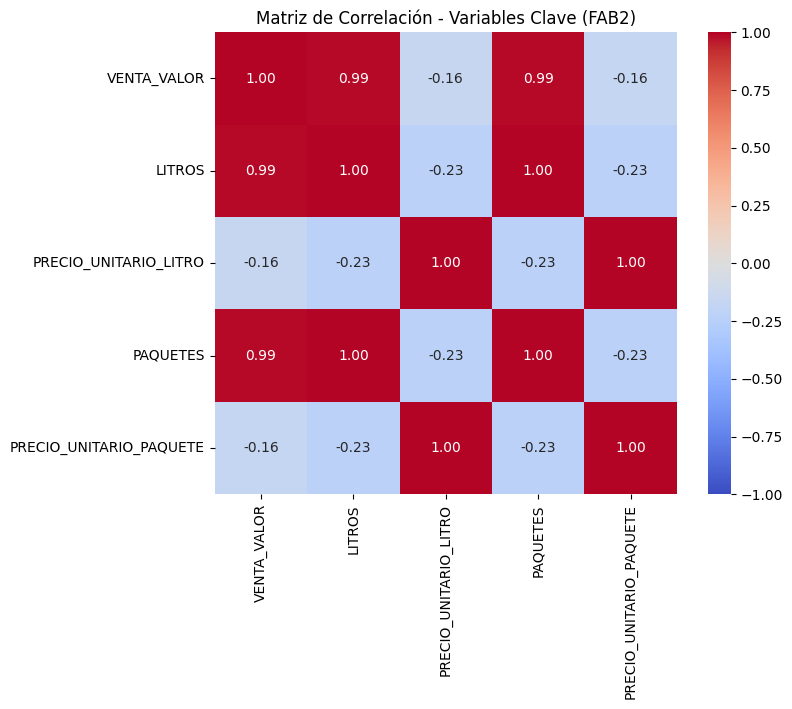

In [ ]:
# Seleccionar únicamente las variables clave para el análisis de correlación
variables_clave = ['VENTA_VALOR', 'LITROS', 'PRECIO_UNITARIO_LITRO',
                    'PAQUETES', 'PRECIO_UNITARIO_PAQUETE']

df_corr = df[variables_clave].copy()

# Calcular la matriz de correlación (Pearson)
matriz_correlacion = df_corr.corr()
display(matriz_correlacion)

# Visualizar con un heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Matriz de Correlación - Variables Clave (FAB2)')
plt.show()

,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE
VENTA_VALOR,1.000000,0.990245,-0.177499,0.990228,-0.181291
LITROS,0.990245,1.000000,-0.289351,0.999954,-0.292686
PRECIO_UNITARIO_LITRO,-0.177499,-0.289351,1.000000,-0.289122,0.997000
PAQUETES,0.990228,0.999954,-0.289122,1.000000,-0.293153
PRECIO_UNITARIO_PAQUETE,-0.181291,-0.292686,0.997000,-0.293153,1.000000


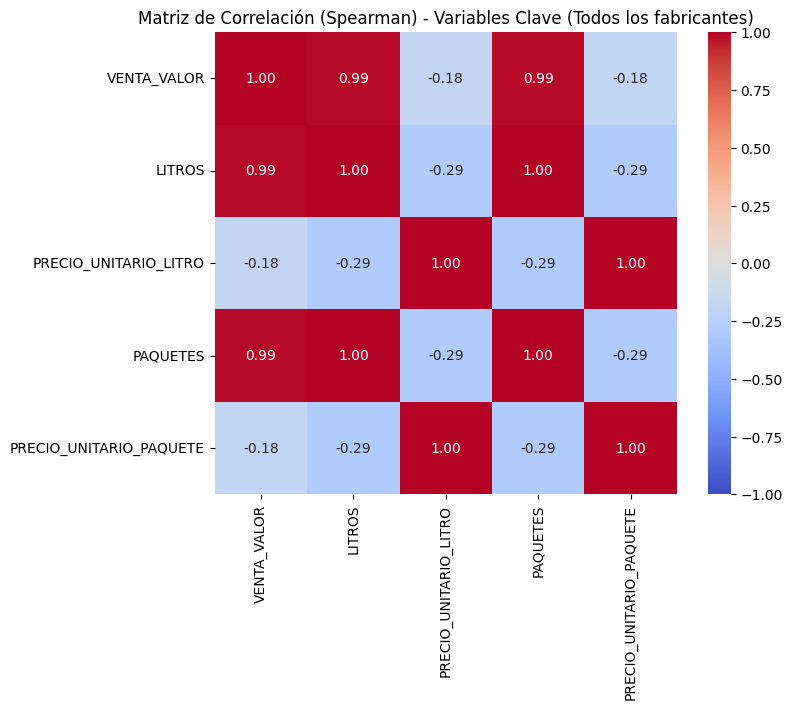

In [ ]:
matriz_correlacion_spearman = df_corr.corr(method='spearman')
display(matriz_correlacion_spearman)

# Visualizar con un heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion_spearman, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Matriz de Correlación (Spearman) - Variables Clave (Todos los fabricantes)')
plt.show()

,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE
VENTA_VALOR,1.000000,0.982836,-0.409786,0.982856,-0.419053
LITROS,0.982836,1.000000,-0.536123,0.999926,-0.542543
PRECIO_UNITARIO_LITRO,-0.409786,-0.536123,1.000000,-0.535489,0.988557
PAQUETES,0.982856,0.999926,-0.535489,1.000000,-0.543502
PRECIO_UNITARIO_PAQUETE,-0.419053,-0.542543,0.988557,-0.543502,1.000000


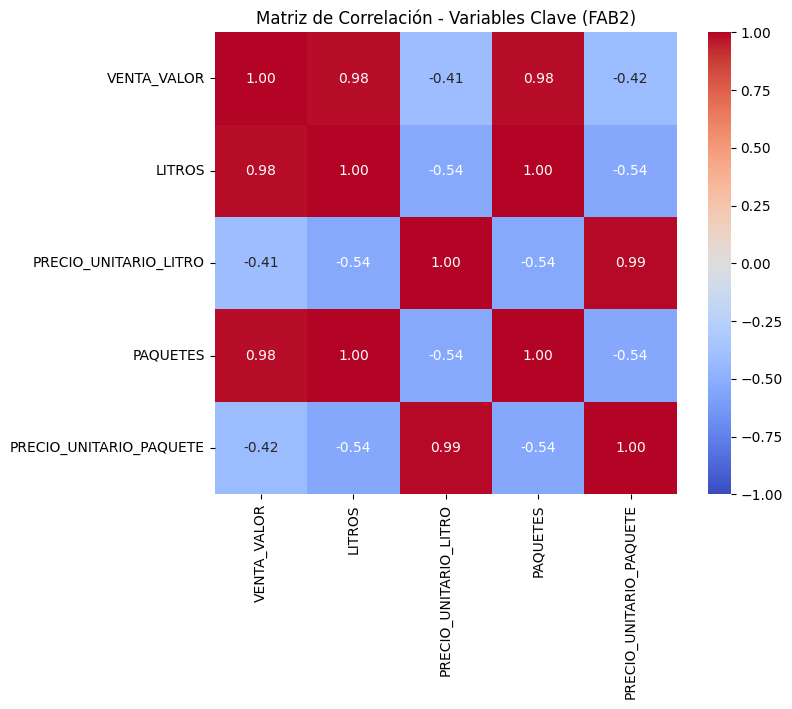

In [ ]:
# Seleccionar únicamente las variables clave para el análisis de correlación
variables_clave = ['VENTA_VALOR', 'LITROS', 'PRECIO_UNITARIO_LITRO',
                    'PAQUETES', 'PRECIO_UNITARIO_PAQUETE']

# df_corr = df_fab2[variables_clave].copy()
df_fab2_clean = df[df['FABRICANTE'] == 'FAB2']
df_corr = df_fab2_clean[variables_clave].copy()

# Calcular la matriz de correlación (Pearson)
matriz_correlacion = df_corr.corr()
display(matriz_correlacion)

# Visualizar con un heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Matriz de Correlación - Variables Clave (FAB2)')
plt.show()

c. Salir de las variables propias: comparar entre competidores

Las cinco variables de arriba son todas del mismo fabricante y varias vienen una de la otra. Para que el análisis sirva de algo tambien hay que ver como se mueven los precios y los volumenes ENTRE fabricantes, porque ahí es donde está la competencia. Lo hacemos sobre el panel mensual para que todos los fabricantes esten en la misma escala de tiempo.

FABRICANTE,FAB1,FAB2,FAB3,FAB5,FAB6
FABRICANTE,,,,,
FAB1,1.000000,0.918944,0.895135,0.271618,0.242904
FAB2,0.918944,1.000000,0.837214,0.436717,0.334375
FAB3,0.895135,0.837214,1.000000,0.408126,0.560550
FAB5,0.271618,0.436717,0.408126,1.000000,NaN
FAB6,0.242904,0.334375,0.560550,NaN,1.000000


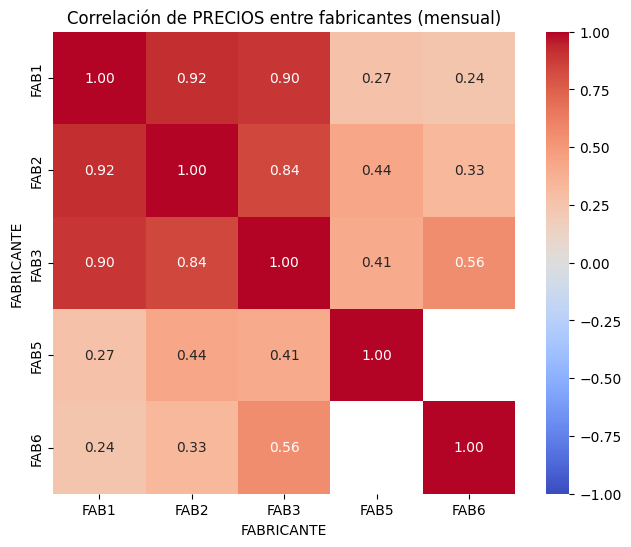

In [ ]:
# Precio ponderado mensual por fabricante
precios_fab = panel_mensual.groupby(['FABRICANTE', 'AÑO_MES'], as_index=False).agg(
    VENTA_VALOR=('VENTA_VALOR', 'sum'),
    LITROS=('LITROS', 'sum'),
)
precios_fab['PRECIO'] = precios_fab['VENTA_VALOR'] / precios_fab['LITROS']

precios_pivot = precios_fab.pivot(index='AÑO_MES', columns='FABRICANTE', values='PRECIO')
corr_precios = precios_pivot.corr()
display(corr_precios)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_precios, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Correlación de PRECIOS entre fabricantes (mensual)')
plt.show()

FABRICANTE,FAB1,FAB2,FAB3,FAB5,FAB6
FABRICANTE,,,,,
FAB1,1.000000,0.409163,0.460181,-0.190916,0.094552
FAB2,0.409163,1.000000,0.285770,-0.704686,0.096004
FAB3,0.460181,0.285770,1.000000,0.117950,0.463547
FAB5,-0.190916,-0.704686,0.117950,1.000000,NaN
FAB6,0.094552,0.096004,0.463547,NaN,1.000000


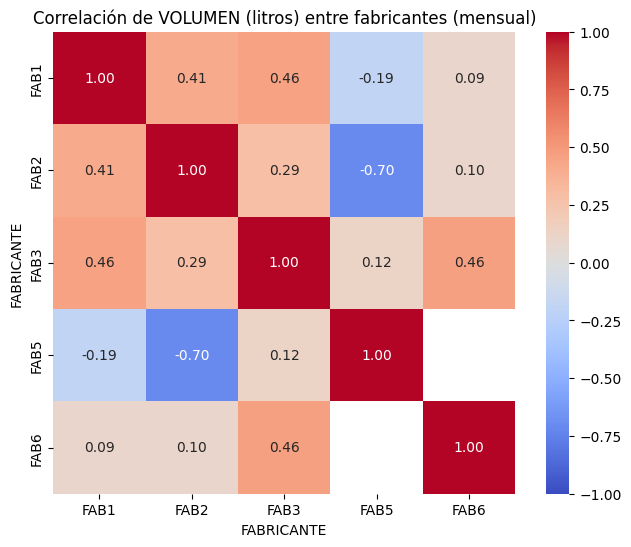

In [ ]:
# Volumen mensual por fabricante
volumen_pivot = precios_fab.pivot(index='AÑO_MES', columns='FABRICANTE', values='LITROS')
corr_volumen = volumen_pivot.corr()
display(corr_volumen)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_volumen, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Correlación de VOLUMEN (litros) entre fabricantes (mensual)')
plt.show()

  **d. Interpretación**

Se muestra una correlación fuerte positiva entre venta-valor y litros, mientras más volumen, más dinero de venta.

Tambien se muestra una correlación negativa entre litros y precio_unitario_litro. Si el precio aumenta, se vende menos. Lo mismo con venta_valor y precio_unitario_paquete, mientras más caro el paquete, menos ingresos en venta_valor van a tener.

Tenemos dos pares de correlación perfectas
  

*  Litros - Paquetes

*  Precio_unitario_litro - Precio-unitario-paquete

Tiene sentido porque una viene de la otra. Tendremos que dropear alguna de estas columnas por pareja para nuestra regresión.

En la matriz de precios entre fabricantes las correlaciones salen muy altas entre FAB1, FAB2 y FAB3, de 0.84 a 0.92. Osea que esos tres suben el precio de la leche practicamente al mismo tiempo, lo cual tiene sentido porque a todos les pega el mismo costo de la materia prima. Con FAB5 y FAB6 la correlación es más baja (entre 0.24 y 0.56), pero es porque ninguno de los dos está presente en todos los meses del panel, FAB6 sale y FAB5 entra, así que se comparan sobre pocos meses. Esto es importante para más adelante: si en el modelo extendido metemos el precio de varios competidores al mismo tiempo, vamos a tener multicolinealidad y el modelo no va a poder separar el efecto de un precio del otro.

En la matriz de volumenes lo interesante es FAB2 contra FAB5, que sale en -0.70. Es una correlación negativa fuerte, cuando uno sube el otro baja, y eso explica justo la caída de nuestro fabricante que vimos en las gráficas de la Etapa 2: el volumen que pierde FAB2 se lo está llevando FAB5, que entró después de que salió FAB6.

Haremos drop a las columnas de paquetes para nuestra regresión.

In [ ]:
columnas_a_dropear = ['PAQUETES', 'PRECIO_UNITARIO_PAQUETE', 'CORTE']

df = df.drop(columns=columnas_a_dropear)

print("Columnas eliminadas:", columnas_a_dropear)
print("Columnas restantes:", df.columns.tolist())

Columnas eliminadas: ['PAQUETES', 'PRECIO_UNITARIO_PAQUETE', 'CORTE']
Columnas restantes: ['FABRICANTE', 'ID', 'PRODUCTO', 'FECHAW', 'FECHAM', 'VENTA_VALOR', 'LITROS', 'PRECIO_UNITARIO_LITRO', 'AÑO_MES', 'AÑO']


## Etapa 3

1. Filtrar datos de FAB2 de los ultimos 12 meses.

Esta ventana de 12 meses la usamos SOLO para identificar cual es el producto top de FAB2, no para recortar la muestra del modelo. El modelo lo vamos a correr sobre el panel mensual completo.

In [ ]:
# Filtrar FAB2 desde la última versión de df (ya limpio)
df_fab2 = df[df['FABRICANTE'] == 'FAB2'].copy()

# Asegurarse de que FECHAW sea datetime
df_fab2['FECHAW'] = pd.to_datetime(df_fab2['FECHAW'])

# Determinar la fecha más reciente disponible en los datos de FAB2
fecha_max = df_fab2['FECHAW'].max()

# Calcular la fecha de corte (12 meses hacia atrás)
fecha_corte = fecha_max - pd.DateOffset(months=12)

# Filtrar los últimos 12 meses
df_fab2_ultimos_12m = df_fab2[df_fab2['FECHAW'] > fecha_corte].copy()

print(f"Rango de fechas: {df_fab2_ultimos_12m['FECHAW'].min()} a {df_fab2_ultimos_12m['FECHAW'].max()}")
print(f"Filas resultantes: {len(df_fab2_ultimos_12m)}")
display(df_fab2_ultimos_12m.head())

Rango de fechas: 2024-07-29 00:00:00 a 2025-07-28 00:00:00
Filas resultantes: 283


,FABRICANTE,ID,PRODUCTO,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,AÑO_MES,AÑO
1355,FAB2,100 Low C Arb,FAB2_ 100 Low C Arb,2024-07-29,2024-08-01,223525.65,9264,24.128416,2024-08,2024
1356,FAB2,100 Low C Arb,FAB2_ 100 Low C Arb,2024-08-05,2024-08-01,185252.96,7536,24.582399,2024-08,2024
1357,FAB2,100 Low C Arb,FAB2_ 100 Low C Arb,2024-08-12,2024-08-01,183298.91,7608,24.092917,2024-08,2024
1358,FAB2,100 Low C Arb,FAB2_ 100 Low C Arb,2024-08-19,2024-08-01,183365.34,7596,24.139724,2024-08,2024
1359,FAB2,100 Low C Arb,FAB2_ 100 Low C Arb,2024-08-26,2024-08-01,198882.62,8088,24.589839,2024-08,2024


2. Sumar el total de ventas de cada producto de FAB2

In [ ]:
# Sumar el total de ventas (VENTA_VALOR) por producto
ventas_por_producto = df_fab2_ultimos_12m.groupby('PRODUCTO')['VENTA_VALOR'].sum().reset_index()
ventas_por_producto = ventas_por_producto.rename(columns={'VENTA_VALOR': 'VENTA_TOTAL'})

# Ordenar de mayor a menor
ventas_por_producto = ventas_por_producto.sort_values(by='VENTA_TOTAL', ascending=False).reset_index(drop=True)

display(ventas_por_producto)

,PRODUCTO,VENTA_TOTAL
0,FAB2_ Deslac Deslactosada 1 L,28096797.87
1,FAB2_12/1L 100 Proteina,26249584.98
2,FAB2_ Light Light 1L,15873707.37
3,FAB2_ 100 Low C Arb,10027577.34
4,FAB2_ Des Light Deslactosada Light 1L,9530186.28
5,FAB2_ Entera Entera 1 L,3460811.92
6,FAB2_ ENTERA 1.5LT 10PZ,1650875.14


3. Elegimos el producto top

#### Deslac Deslactosada 1

4. Modelo de regresión

In [ ]:
import statsmodels.api as sm
import numpy as np

# 1. Identificar el producto top (mayor venta en los últimos 12 meses)
producto_top = ventas_por_producto.iloc[0]['PRODUCTO']
print(f"Producto top: {producto_top}")

# 2. El modelo se estima sobre el PANEL MENSUAL completo, no sobre las semanas del último año
df_top_producto = panel_mensual[
    (panel_mensual['FABRICANTE'] == 'FAB2') & (panel_mensual['PRODUCTO'] == producto_top)
].copy()
df_top_producto = df_top_producto.sort_values('AÑO_MES').reset_index(drop=True)

print(f"Meses disponibles para el modelo: {len(df_top_producto)}")
print(f"Rango: {df_top_producto['AÑO_MES'].min()} a {df_top_producto['AÑO_MES'].max()}")

# 3. Transformación logarítmica (modelo log-log para estimar elasticidad directa)
df_top_producto['log_LITROS'] = np.log(df_top_producto['LITROS'])
df_top_producto['log_PRECIO'] = np.log(df_top_producto['PRECIO_UNITARIO_LITRO'])

# 4. Definir variable dependiente (Y) e independiente (X)
Y = df_top_producto['log_LITROS']
X = df_top_producto['log_PRECIO']
X = sm.add_constant(X)  # Agrega el intercepto al modelo

# 5. Ajustar el modelo de regresión (OLS)
modelo_elasticidad = sm.OLS(Y, X).fit()

# 6. Resultados
print(modelo_elasticidad.summary())

# 7. Extraer el coeficiente de elasticidad-precio directamente
elasticidad_precio = modelo_elasticidad.params['log_PRECIO']
print(f"\nElasticidad-precio estimada: {elasticidad_precio:.4f}")

Producto top: FAB2_ Deslac Deslactosada 1 L
Meses disponibles para el modelo: 43
Rango: 2022-01 a 2025-07
                            OLS Regression Results                            
Dep. Variable:             log_LITROS   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.645
Method:                 Least Squares   F-statistic:                     77.24
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           5.63e-11
Time:                        04:15:34   Log-Likelihood:                0.92591
No. Observations:                  43   AIC:                             2.148
Df Residuals:                      41   BIC:                             5.671
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

# Interpretación

La cantidad de litros que se venden disminuye si el precio aumenta. Eso lo habíamos notado previamente cuando veíamos el market share de los últimos años. El coeficiente de log_PRECIO nos dice que si el precio aumenta 1%, disminuye -3.23%. Estamos hablando de una demanda elástica, el precio tiene un efecto bastante fuerte sobre cuánto se vende.

Este modelo lo corrimos sobre los 43 meses del panel mensual.

Para confirmar esto planteamos la hipótesis nula H0: el precio no tiene efecto sobre la demanda (log_PRECIO = 0).

- H0 -> log_PRECIO = 0

- Ha -> log_PRECIO != 0

El p-value nos da 0, así que rechazamos esa hipótesis nula con mucha confianza. El t-statistic da -8.789, pero hay que tener claro que el t tampoco nos dice que tan grande es el efecto: el t es el coeficiente dividido entre su error estándar, osea mide que tan lejos está el coeficiente del cero en unidades de precisión. El tamaño del efecto es el coeficiente mismo -3.23 y su rango plausible es el intervalo de confianza al 95%, que es [-3.976,     -2.490]. Con 95% de confianza el efecto real está en ese rango, y en ese rango no tenemos el 0, lo que nos ayuda a verificar que podemos rechazar la hipotesis unla.

El R2 nos dice en que proporción de la variación de log(litros) queda explicada por el modelo, y aquí nos da 0.65, osea el precio por si solo explica el 65% de los movimientos del volumen. El otro 35% se queda sin explicar, y nos deja la posibilidad de que existan más factores en esta situación, como la época del año o la tendencia del producto, que son los que vamos a meter en la Etapa 4.

También hay que preguntarnos qué tan creible es esta elasticidad. Ahora la estamos estimando con 43 meses en lugar de 53 semanas de un solo año, así que es más confiable que la primera vez, pero sigue siendo una muestra chica y el modelo todavía no controla por nada más que el precio, así que hay que analizarlo antes de usarlo para tomar decisiones de precio.

## Etapa 4

1. Propuesta de diseño

El objetivo de agregar variables no es que la elasticidad salga más grande, es estimarla SIN SESGO. Que el numero crezca o se encoja al agregar controles no es una mejora por si sola, lo que mejora es que el coeficiente del precio deje de cargar con efectos que no le corresponden, como la época del año o la tendencia del producto.

La ecuación que propongo es:

ln(Litros_t) = β0 + β1·ln(Precio_t) + Σ_j γ_j·ln(Precio_competidor_j,t) + Σ_m δ_m·Mes_m,t + θ·t + ε_t

- β1 es la elasticidad precio directa, el cambio porcentual en litros ante un cambio de 1% en nuestro precio, manteniendo lo demás constante.

- γ_j es la elasticidad cruzada con el competidor j. Si sale positiva, el producto del competidor es un sustituto, porque cuando su precio sube nosotros vendemos más. Si sale negativa seria un complemento.

- δ_m son las dummies de mes y capturan la estacionalidad. Van 11 y no 12, porque un mes se queda como base y si metemos los 12 junto con el intercepto caemos en la trampa de la variable dummy. Cada δ_m se lee como la diferencia de ese mes contra el mes base.

- θ es la tendencia, un contador (1, 2, 3, ...) que mide si el producto gana o pierde volumen de forma estructural con el paso del tiempo.

- Precio de producto diferente

    Asi como tenemos en nuestra formula de regresión la variable del precio de nuestro top producto, agregariamos una igual pero con un producto diferente, por si el usuario prefiere otra marca al ver el incremente de precio. Si el coeficiente de esta nueva variable es positivo confirmariamos que el nuevo producto es un sustituto del nuestro.

    Para escoger a los competidores no meteria a todos. Tomaria los productos top de los fabricantes que forman el 80% del mercado en los ultimos 12 meses (FAB1, FAB3 y FAB5) y que ademas sean del mismo segmento que el nuestro, leche de 1 L, porque son los que de verdad pelean por el mismo consumidor.

- Estacionalidad

    Es la parte de las dummies de mes. Nos permite ver en que mes, sin importar el precio, los usuarios siguen comprando leche. Por ejemplo, para navidad las ventas podrian incrementar por la epoca sin importar si el precio aumenta. Es un patrón que se repite todos los años.

- Tendencia de crecimiento

    Seria un variable constante que nos indica desde cuando comenzamos a contar. Nos ayuda a determinar si la leche va ganando "popularidad" o va decreciendo a lo largo del tiempo. No es lo mismo que la estacionalidad: la estacionalidad se repite cada año y la tendencia es el movimiento de largo plazo que no se repite.

- Riesgo de multicolinealidad

    En las correlaciones vimos que los precios de los fabricantes se mueven casi igual entre ellos. Si metemos varios precios de competidores al mismo tiempo, el modelo no va a poder separar el efecto de uno del efecto del otro, los errores estándar se inflan y los coeficientes se vuelven inestables. Una solución es usar el precio relativo, ln(precio nuestro / precio del competidor), que mide si estamos caros o baratos contra el mercado en vez de meter los dos precios por separado.

    Tambien hay que cuidar los grados de libertad. Solo tenemos 43 meses, y entre el intercepto, el precio, la tendencia y las 11 dummies ya nos gastamos 14 parámetros. Si encima le agregamos 3 o 4 precios de competidores nos queda muy poquita información para estimar todo con precisión.

In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# 1. Partimos del mismo df_top_producto del modelo simple (panel mensual completo)
df_top_ext = df_top_producto.copy()
df_top_ext = df_top_ext.sort_values('AÑO_MES').reset_index(drop=True)

# 2. Variable dependiente e independiente base (igual que antes)
df_top_ext['log_LITROS'] = np.log(df_top_ext['LITROS'])
df_top_ext['log_PRECIO'] = np.log(df_top_ext['PRECIO_UNITARIO_LITRO'])

# 3. Variable de TENDENCIA: contador de MESES (1, 2, 3... por cada mes ordenado)
df_top_ext['trend'] = np.arange(1, len(df_top_ext) + 1)

# 4. Variables de ESTACIONALIDAD: dummies por mes, sacadas del mes del panel (FECHAM)
df_top_ext['MES'] = df_top_ext['AÑO_MES'].dt.month
mes_dummies = pd.get_dummies(df_top_ext['MES'], prefix='mes', drop_first=True)
# drop_first=True evita la trampa de la variable dummy (colinealidad perfecta)

df_top_ext = pd.concat([df_top_ext, mes_dummies], axis=1)

# 5. Construir matriz de variables explicativas: precio + tendencia + estacionalidad
X_cols = ['log_PRECIO', 'trend'] + list(mes_dummies.columns)
X = df_top_ext[X_cols].astype(float)
X = sm.add_constant(X)

Y = df_top_ext['log_LITROS']

# 6. Ajustar el modelo extendido
modelo_extendido = sm.OLS(Y, X).fit()
print(modelo_extendido.summary())

# 7. Comparar la elasticidad-precio antes vs. después de controlar por estacionalidad y tendencia
elasticidad_extendida = modelo_extendido.params['log_PRECIO']
print(f"\nElasticidad-precio (modelo simple):    {elasticidad_precio:.4f}")
print(f"Elasticidad-precio (modelo extendido): {elasticidad_extendida:.4f}")

                            OLS Regression Results                            
Dep. Variable:             log_LITROS   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.626
Method:                 Least Squares   F-statistic:                     6.415
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           1.63e-05
Time:                        04:15:34   Log-Likelihood:                 7.2822
No. Observations:                  43   AIC:                             13.44
Df Residuals:                      29   BIC:                             38.09
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.7416      3.817      7.268      0.0

# Interpretación

Con la incorporación de estos nuevos factores, podemos ver en nuestro R2 que estos factores juntos explican en 74% el porque la demanda de litros aumenta o disminuye, subió de 65% en el modelo simple a 74% aquí. Pero el R2 solo no sirve para comparar los dos modelos, porque sube nomas por agregar parámetros. Por eso miramos el R2 ajustado, que pasó de 0.645 a 0.626, osea que BAJÓ. Eso nos dice que las 12 variables que agregamos no pagan lo que cuestan en grados de libertad si lo único que nos importara fuera el ajuste. La razón para quedarnos con este modelo no es que ajuste mejor, es que el coeficiente del precio ya no carga con efectos que no son suyos.

El coeficiente de precio pasó de -3.23 a -5.47, es decir, ahora por cada 1% que el precio aumenta, la demanda de litros disminuye 5.47%. En el modelo simple el precio venía cargando con efectos que no eran suyos, el calendario y la tendencia, y al controlarlos el coeficiente se queda solo con lo que sí le toca.

Para confirmar esto planteamos la hipótesis nula H0: el precio no tiene efecto sobre la demanda, controlando por mes y tendencia.

- H0 -> log_PRECIO = 0

- Ha -> log_PRECIO != 0

El p-value nos da 0.000, así que rechazamos esa hipótesis nula. El t-statistic de log_PRECIO es -4.05, y el intervalo de confianza al 95% para la elasticidad es [-8.230, -2.707]. Con 95% de confianza el efecto real está en ese rango, y no incluye el 0, lo que nos ayuda a verificar que podemos rechazar la hipótesis nula.

Algo que hay que notar es que el coeficiente ganó magnitud pero perdió precisión. El t-statistic pasó de -8.789 a -4.05 y el intervalo se abrió de [-3.976, -2.490] a [-8.230, -2.707], que es un rango amplisimo, va de una elasticidad de -2.7 a una de -8.2. Esto pasa porque metimos 12 variables más sobre las mismas 43 observaciones, nos quedamos con 29 grados de libertad y el error estándar del precio se infló de 0.368 a 1.350.

Hacemos lo mismo para la tendencia, planteando H0: no hay tendencia en el tiempo.

- H0 -> trend = 0

- Ha -> trend != 0

El p-value de trend es 0.098, así que NO rechazamos H0 al 5%. El coeficiente es 0.0187 y su intervalo es [-0.004, 0.041], que sí incluye el cero. Osea que con estos datos no tenemos evidencia de que el producto tenga una tendencia estructural una vez que controlamos por el precio. Si el coeficiente fuera significativo, al estar el modelo en logaritmos se leería como que el volumen sube más o menos 1.9% cada mes por razones que no son el precio ni la temporada, pero no podemos afirmarlo.

Para cada mes planteamos H0: ese mes se comporta igual que enero, que es el mes base. Aquí no podemos rechazar H0 para ningún mes, todos los p-values quedan arriba de 0.05. Los que más se acercan son septiembre (0.086) y agosto (0.095), que son los meses con el coeficiente más alto, pero no alcanzan. Con solo 43 observaciones y 11 dummies no tenemos suficiente información para separar bien el efecto de cada mes.

Lo interesante es que ni la tendencia ni los meses salen significativos por separado, y aun así mover el modelo de -3.23 a -5.47 sí importa. Eso es justo lo que se espera del sesgo por variable omitida: no hace falta que el control sea significativo para que su ausencia contamine al precio.

También hay que preguntarnos qué tan creíble es esta nueva elasticidad de -5.47, ya que sigue siendo un número grande y su intervalo es muy ancho. Ahora al menos la estamos estimando con los 43 meses completos y controlando por tendencia y temporada, pero el modelo todavía no incluye los precios de los competidores, que es justo lo que propusimos en el diseño, así que hay que analizarlo antes de usarlo para tomar decisiones de precio.

**Did the estimates of direct price elasticity change compared with the previous model? What happened with the statistical significance of the price elasticity? Why do you think the estimates change, and which estimate is the best? Explain clearly with your own words.**

Si cambió la estimación, de -3.23 pasó a -5.47. El precio sigue siendo la variable que más pesa sobre la demanda de la leche en los dos modelos, de hecho es la única que sale significativa en el modelo extendido.

El p-value del precio se mantuvo en 0.000 en los dos modelos, así que en los dos rechazamos H0 y confirmamos que el precio sí importa. Pero la significancia no se quedó igual de fuerte: el t-statistic bajó de -8.789 a -4.05 y el intervalo de confianza se abrió de [-3.976, -2.490] a [-8.230, -2.707]. Osea que el coeficiente ganó magnitud pero perdió precisión, porque estamos estimando 14 parámetros con 43 observaciones y nos quedan solo 29 grados de libertad.

En el primer modelo, al tener solo una variable explicativa, estábamos teniendo sesgo sobre el precio, ya que toda la dependencia caía sobre este. Ese es el sesgo por variable omitida: el coeficiente del precio se estaba quedando con el efecto de la tendencia y de la temporada, que no le correspondian. Al incorporar las otras variables de tendencia y temporada, la "dependencia" se distribuyó entre diferentes variables. Esto nos permitió entender CUÁNTO importa el precio en estas relaciones. Y algo que vale la pena notar es que ni la tendencia ni las dummies de mes salieron significativas por su cuenta, y aun así el coeficiente del precio se movió de -3.23 a -5.47. No hace falta que un control sea significativo para que su ausencia contamine al precio.

El mejor modelo es el segundo, pero no porque su R2 esté más cerca de 1. Un R2 alto puede venir nomas de haber agregado parámetros, de hecho nuestro R2 ajustado ni siquiera subió, bajó de 0.645 a 0.626, y aparte el R2 no nos dice nada sobre si el coeficiente del precio está sesgado. El argumento bueno es el de arriba: el modelo con controles es mejor porque ya no le atribuye al precio efectos que en realidad son de la tendencia o del calendario, entonces su elasticidad es la que sí podriamos usar para pensar en una decisión de precio, aunque con la reserva de que el intervalo es muy ancho.

# Forecast price and sales of the top product

## Tree-Based Ensembles

Eligiria la tecnica de "Tree-Based Ensembles" para predecir el precio y venta del producto principal de mi fabricante para los siguientes 24 meses.

El Tree-Based Ensembles es una tecnica de machine learning que combina multiples arboles de decisión para hacer mejores predicciones. Son muchos arboles de decisión que pueden llegar a corregirse mutuamente, las fortalezas de uno, son las debilidades del otro.

Este tipo de solución funciona de una manera diferente, crea pronosticos recursivos, necesita de un periodo de tiempo para poder predecir el siguiente. Este enfoque nos permitirira experimentar los cambios de demanda apartir de temporada. Tendremos muchos arboles de decisiones apartir de los factores que tomemos en cuenta.

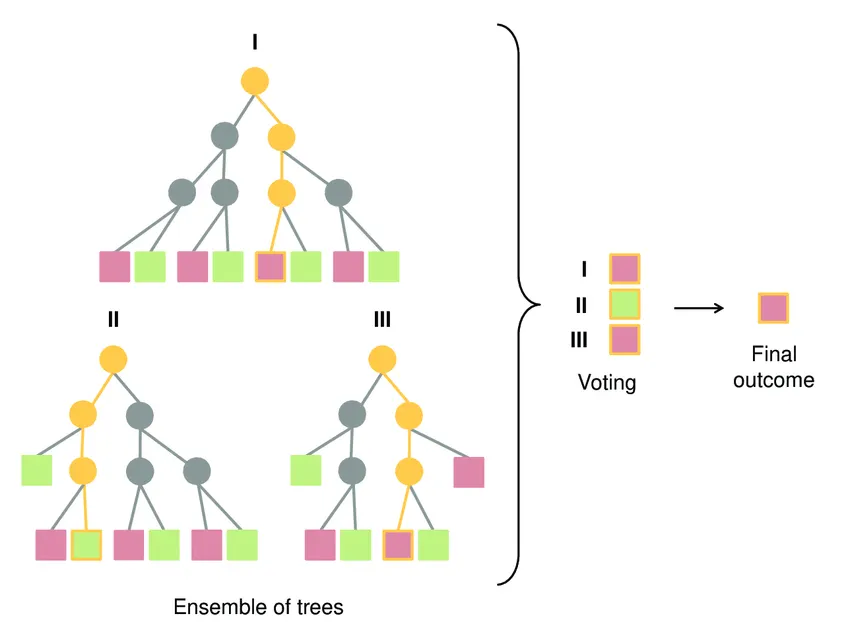


Citas:

Lu, H., & Zhou, S. (2022). 7. Trees and ensembles. In Intro to transparent ML course. The Alan Turing Institute. https://alan-turing-institute.github.io/Intro-to-transparent-ML-course/07-trees-ensembles/overview.html

Pankaj. (2023, August 21). Decision tree ensemble model. Medium. https://medium.com/@pankaj_pandey/decision-tree-ensemble-model-f422ba280fa8

